This dataset contains
- Loading datasets
- EDA
- feature engineering
- graph building

# ❤ LOADING DATASETS

In [ ]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import skew, kurtosis
from scipy.spatial.distance import cosine
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings("ignore")

In [ ]:
GOOGLE_PATH = "/content/drive/MyDrive/kosciuszkon/A DATASET for GPS Spoofing Detection on Unmanned Aerial System"

In [ ]:
# reading into files
gps_authentic_path = GOOGLE_PATH + "/GPS_Authentic_Data_3D_8_Channels.xlsx"
gps_data_path = GOOGLE_PATH + "/GPS_Data_Simplified_2D_Feature_Map.xlsx"
gps_dataset_path = GOOGLE_PATH + "/GPS_Dataset_3D_8_Channels_Authentic_and_Simulated.xlsx"

In [ ]:
raw_authentic = pd.read_excel(gps_authentic_path)

In [23]:
raw_authentic

,PRN,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Carrier_Doppler_hz,Unnamed: 9,...,Unnamed: 94,Unnamed: 95,CN0,Unnamed: 97,Unnamed: 98,Unnamed: 99,Unnamed: 100,Unnamed: 101,Unnamed: 102,Unnamed: 103
0,ch0,ch1,ch2,ch3,ch4,ch5,ch6,ch7,ch0,ch1,...,ch6,ch7,ch0,ch1,ch2,ch3,ch4,ch5,ch6,ch7
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159141,0,4,7,0,0,9,27,16,0,-1116.036508,...,2782.778076,-1220.740356,0,43.014034,46.471382,0,0,47.53558,46.202217,45.302437
159142,0,4,7,0,0,9,27,16,0,-1114.578931,...,2786.121338,-1217.116089,0,43.035362,46.537384,0,0,47.504826,46.220734,45.384525
159143,0,4,7,0,0,9,27,16,0,-1114.109882,...,2781.912842,-1220.933716,0,42.942539,46.470272,0,0,47.490456,46.227245,45.361202
159144,0,4,7,0,0,9,27,16,0,-1116.907519,...,2783.154785,-1223.381714,0,42.829323,46.359314,0,0,47.505035,46.291912,45.369606


In [24]:
data_2d =  pd.read_excel(gps_data_path)

In [25]:
main_3d = pd.read_excel(gps_dataset_path)

print("main_3d shape:", main_3d.shape)
print("main_3d columns:", main_3d.columns.tolist())

main_3d shape: (158176, 112)
main_3d columns: ['PRN', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Carrier_Doppler_hz', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Pseudorange_m', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'RX_time', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27', 'Unnamed: 28', 'Unnamed: 29', 'Unnamed: 30', 'Unnamed: 31', 'TOW_at_current_symbol_s', 'Unnamed: 33', 'Unnamed: 34', 'Unnamed: 35', 'Unnamed: 36', 'Unnamed: 37', 'Unnamed: 38', 'Unnamed: 39', 'Carrier_phase_cycles', 'Unnamed: 41', 'Unnamed: 42', 'Unnamed: 43', 'Unnamed: 44', 'Unnamed: 45', 'Unnamed: 46', 'Unnamed: 47', 'EC', 'Unnamed: 49', 'Unnamed: 50', 'Unnamed: 51', 'Unnamed: 52', 'Unnamed: 53', 'Unnamed: 54', 'Unnamed: 55', 'LC', 'Unnamed: 57', 'Unnamed: 58', 'Unnamed: 59', 'Unnamed: 60', 'Unnamed: 61', 'Unnamed: 62', 'Unnamed: 63', '

# ❤ EDA FOR 2D DATASET

In [26]:
"""
PRN - id satelity
DO - Hz - Przesunięcie częstotliwości z ruchu satelity
PD - Odległość odbiorca - satelita na podstawie czasu propagacji
RX - receiver time - czas odbiornika
TOW - time of week - GPS timestamp tygodniowy
CP - faza nośna sygnału
EC - amplituda korelatora wczesnego - kształt korelacji
LC - amplituda korelatora późnego - kształt korelacji
PC - amplituda korelatora centralnego - siła sygnału
PIP - składowa I sygnału w korelatorze
PQP - składowa Q sygnału w korelatorze
TCD - Doppler w pętli śledzenia
C/No - Stosunek sygnału do szumu - kluczowy wskaźnik jakości

"""

'\nPRN - id satelity\nDO - Hz - Przesunięcie częstotliwości z ruchu satelity\nPD - Odległość odbiorca - satelita na podstawie czasu propagacji\nRX - receiver time - czas odbiornika\nTOW - time of week - GPS timestamp tygodniowy\nCP - faza nośna sygnału\nEC - amplituda korelatora wczesnego - kształt korelacji\nLC - amplituda korelatora późnego - kształt korelacji\nPC - amplituda korelatora centralnego - siła sygnału\nPIP - składowa I sygnału w korelatorze\nPQP - składowa Q sygnału w korelatorze\nTCD - Doppler w pętli śledzenia\nC/No - Stosunek sygnału do szumu - kluczowy wskaźnik jakości\n\n'

In [27]:
# Dataset Size
data_2d.shape

(510530, 14)

As we can see - the dataset contains 510530 rows and 14 columns

In [28]:
data_2d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 510530 entries, 0 to 510529
Data columns (total 14 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   PRN     510530 non-null  int64  
 1   DO      510530 non-null  float64
 2   PD      510530 non-null  float64
 3   RX      510530 non-null  float64
 4   TOW     510530 non-null  float64
 5   CP      510530 non-null  float64
 6   EC      510530 non-null  float64
 7   LC      510530 non-null  float64
 8   PC      510530 non-null  float64
 9   PIP     510530 non-null  float64
 10  PQP     510530 non-null  float64
 11  TCD     510530 non-null  float64
 12  CN0     510530 non-null  float64
 13  Output  510530 non-null  int64  
dtypes: float64(12), int64(2)
memory usage: 54.5 MB


In [29]:
data_2d.duplicated().sum()

np.int64(31218)

Dataset contains no missing values but there are 31218 duplicated values. Let's display them :

In [30]:
duplicates = data_2d[data_2d.duplicated()]

print(duplicates)

        PRN           DO            PD         RX          TOW            CP  \
171349   26 -1441.392793 -2.354659e+06  173795.98  173795.9879   30683.75548   
171350    4  1114.727543 -3.875499e+06  173796.00  173796.0129  -25686.35569   
171352   26 -1441.702981 -2.353933e+06  173796.00  173796.0079   30699.17464   
171353    4  1112.329822 -3.875504e+06  173796.02  173796.0329  -25708.64573   
171355   26 -1441.860904 -2.353928e+06  173796.02  173796.0279   30728.01461   
...     ...          ...           ...        ...          ...           ...   
228043   27  4718.023531  2.649701e+07  174233.78  174233.6916 -588140.55790   
228047   27  4748.151335  2.649699e+07  174233.80  174233.7116 -588234.93770   
228051   27  4738.417035  2.649697e+07  174233.82  174233.7316 -588329.55720   
228055   27  4729.486139  2.649696e+07  174233.84  174233.7516 -588424.42950   
228059   27  4748.864054  2.649694e+07  174233.86  174233.7716 -588519.56100   

                 EC           LC       

As we can see there are some duplicated values. Due to our concern, we decided to drop duplicates as ~ 30k should not be "major" loss, since we have 500k rows, but just to be safe - we decided to keep original dataset.

In [31]:
data_2d_nodupp = data_2d.drop_duplicates()

In [32]:
# check
data_2d_nodupp.shape

(479312, 14)

In [33]:
# stats
data_2d_nodupp.describe()

,PRN,DO,PD,RX,TOW,CP,EC,LC,PC,PIP,PQP,TCD,CN0,Output
count,479312.000000,479312.000000,4.793120e+05,479312.000000,479312.000000,4.793120e+05,479312.000000,479312.000000,479312.000000,479312.000000,479312.000000,479312.000000,479312.000000,479312.000000
mean,14.217796,1353.739371,7.438671e+06,289741.635331,289741.612028,-1.276702e+05,107828.982010,107799.325924,119391.775303,-49.615407,66.596033,1362.784889,44.702881,0.461007
std,9.134139,2333.767396,9.574086e+06,106578.411869,106578.407459,2.418345e+05,31430.548168,31277.363379,33715.273556,121920.861913,24144.573397,2319.612345,2.887681,0.913131
min,2.000000,-4262.754835,-6.588428e+06,173640.000000,173640.008000,-1.032332e+06,-11261.148740,-12557.513790,318.674133,-270777.625000,-216012.859900,-3214.671400,0.000000,0.000000
25%,7.000000,-861.434991,2.410861e+06,262780.460000,262780.443925,-2.631994e+05,86563.554407,86620.865237,96759.468750,-119419.736325,-11901.046492,-857.431839,43.203504,0.000000
50%,11.000000,1481.174674,3.730613e+06,263387.540000,263387.525250,-1.039360e+05,109578.101900,109535.484400,121594.601600,-2241.402815,36.592880,1482.158447,45.328023,0.000000
75%,26.000000,3463.115664,6.091284e+06,263879.640000,263879.621850,6.014368e+04,130456.953100,130316.931650,143764.267500,119399.894525,11961.556642,3460.039856,46.640760,0.000000
max,31.000000,6715.759846,2.830762e+07,492039.420000,492039.341092,3.527992e+05,244872.734400,244650.390600,271466.125000,242361.078100,226761.110000,5260.343750,50.482834,3.000000


The most important fact is that we have 4 different labels in "Output" column - 0,1,2,3 that represents <br>
0 Authentic — real GPS signal, no attack <br>
1 Simplistic attack — the simplest attack, spoofer transmits one signal from a fixed position <br>
2 Intermediate attack — more advanced attack, spoofer tracks the receiver's movement <br>
3 Sophisticated attack — the most advance attack, simulates multiple satellites simultaneously <br>

CN0 values indicate generally strong satellite signal quality, while deviations may indicate spoofing-related signal inconsistencies.

<Axes: xlabel='Output', ylabel='CN0'>

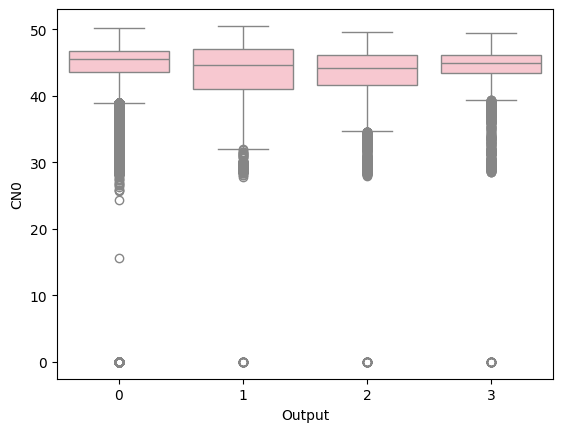

In [ ]:
# spoofed vs normal
sns.boxplot(x="Output", y="CN0", data=data_2d_nodupp, color='pink')

The diversity of signal measurements enables both classical machine learning and advanced deep learning approaches.

In [ ]:
# class percent
data_2d_nodupp["Output"].value_counts(normalize=True) * 100

,proportion
Output,
0,76.486297
2,9.228227
1,7.606110
3,6.679365


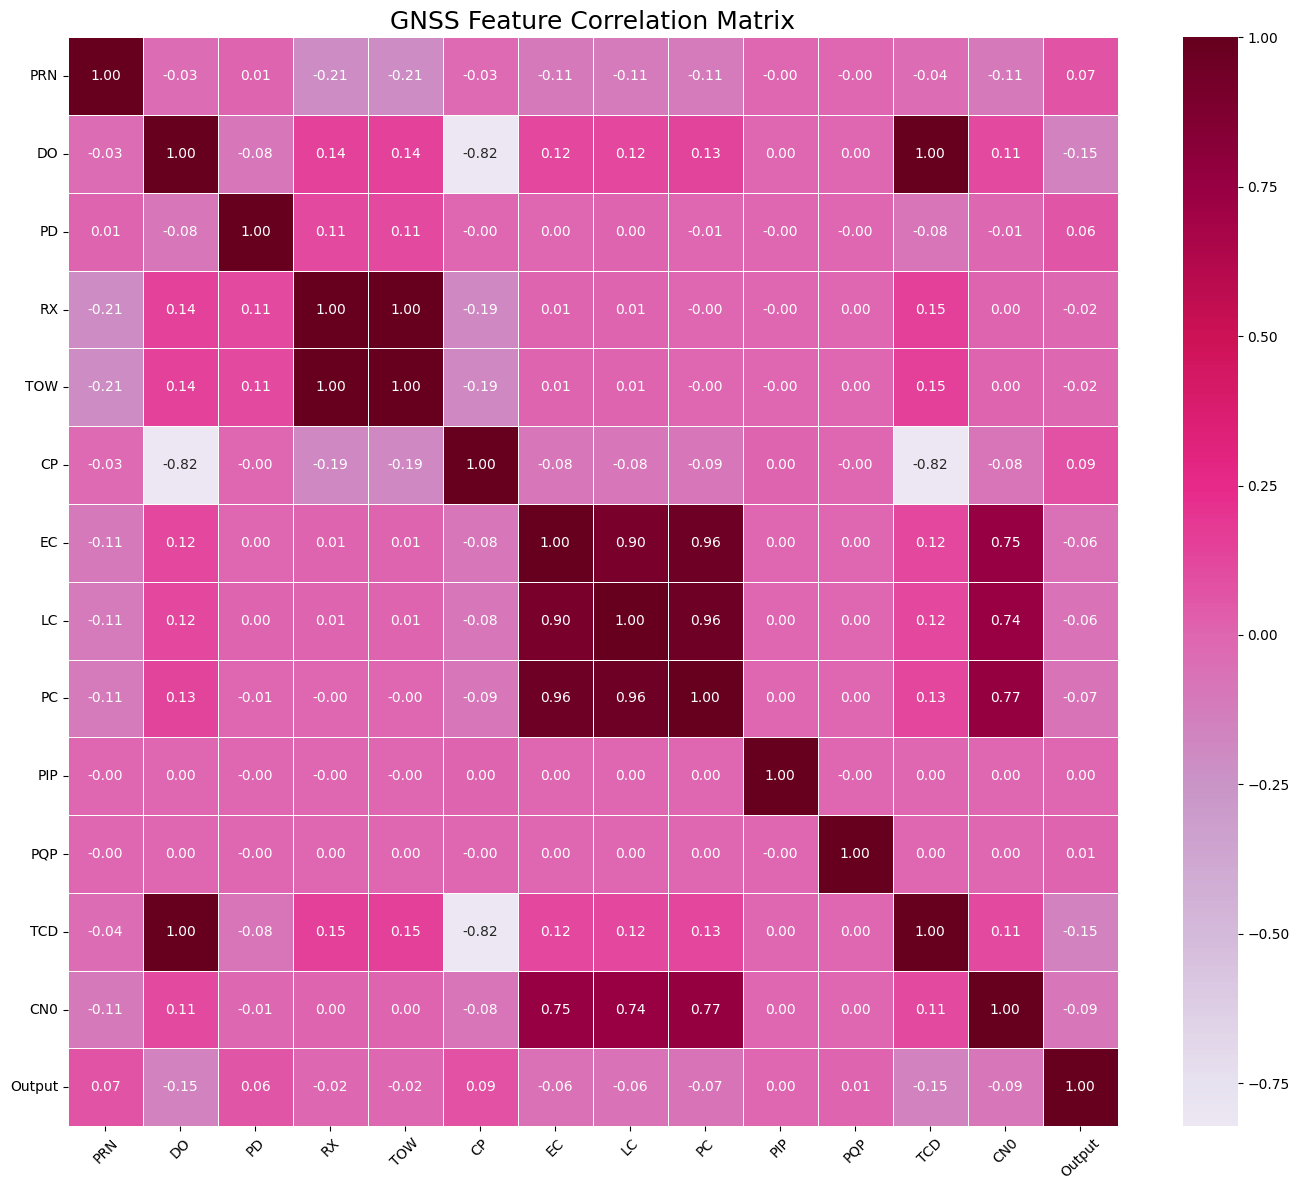

In [ ]:
corr = data_2d_nodupp.corr(numeric_only=True)

plt.figure(figsize=(14,12))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="PuRd",
    center=0,
    linewidths=0.5
)

plt.title("GNSS Feature Correlation Matrix", fontsize=18)
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

<Axes: xlabel='CN0', ylabel='Count'>

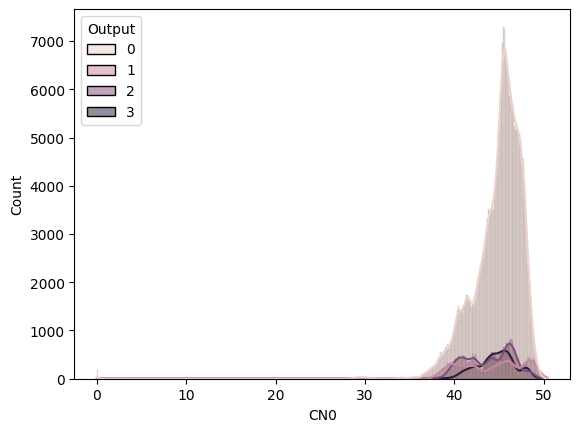

In [ ]:
sns.histplot(
    data=data_2d_nodupp,
    x="CN0",
    hue="Output",
    kde=True
)

/tmp/ipykernel_10134/3483663077.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  spoofed = data_2d_nodupp[:3000][data_2d["Output"] != 0]


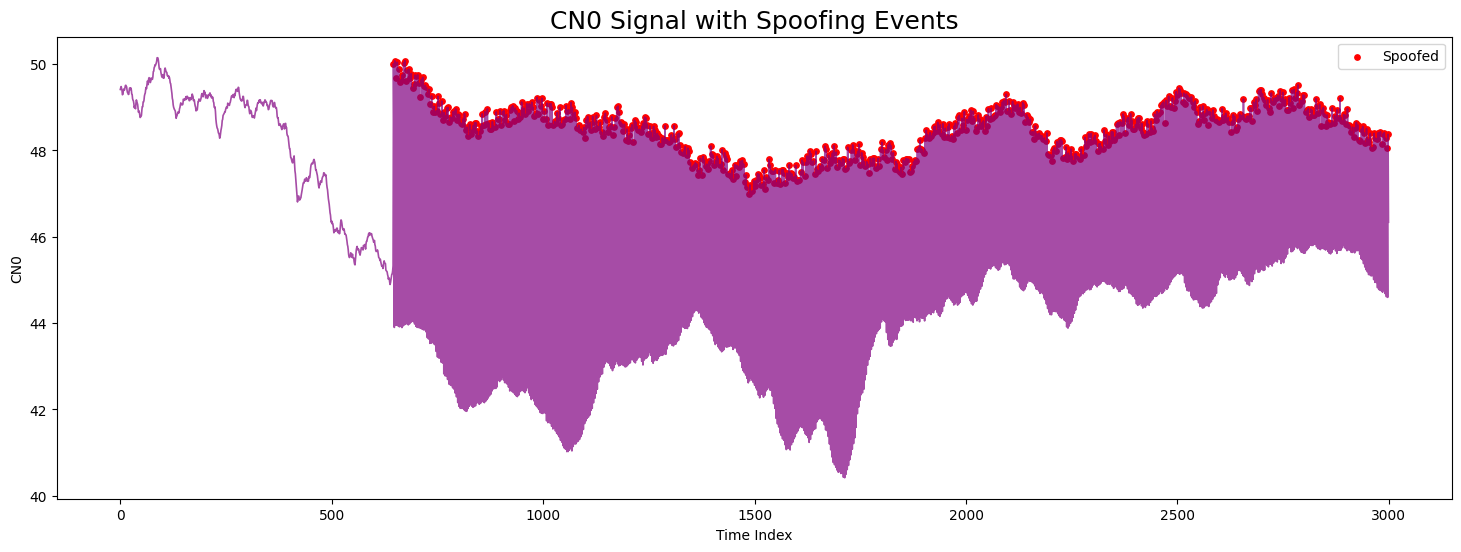

In [ ]:
plt.figure(figsize=(18,6))

plt.plot(
    data_2d_nodupp.index[:3000],
    data_2d_nodupp["CN0"][:3000],
    color="purple",
    linewidth=1.2,
    alpha=0.7
)
spoofed = data_2d_nodupp[:3000][data_2d["Output"] != 0]

plt.scatter(
    spoofed.index,
    spoofed["CN0"],
    color="red",
    s=15,
    label="Spoofed"
)

plt.title("CN0 Signal with Spoofing Events", fontsize=18)

plt.xlabel("Time Index")
plt.ylabel("CN0")

plt.legend()

plt.show()

In [ ]:
# number of unique values
print("Number of unique values for each column")
data_2d_nodupp.nunique()

Number of unique values for each column


,0
PRN,19
DO,449530
PD,455115
RX,94942
TOW,434792
CP,461665
EC,439654
LC,439435
PC,438556
PIP,441164


Full analysis:
The EDA showed that the dataset is well-suited for GPS spoofing detection tasks. The dataset contains multiple GNSS signal-related features, including carrier phase (CP), pseudorange-related measurements (PD, PC), timing information (RX, TOW), and signal quality metrics such as CN0. Dataset also contains both normal and anomaly values, with normal (not-attacked) values are more common (~78%),
mild attacks (~7%), intermediate attacks (~9%), advanced attacks(6%).

Statistical analysis shows substantial variability across several signal parameters, suggesting that spoofing attacks introduce measurable disruptions in GNSS behavior.

The correlation analysis revealed strong relationships between several features, particularly EC, LC, PC, and CN0, while some features such as CP and TCD showed strong negative correlations. These dependencies indicate that spoofing attacks may alter the natural relationships between GNSS signals making the dataset highly suitable for graph-based and deep learning approaches such as GNNs and temporal models. For GNN models we will use 3D dataset (same rows and columns) that will be introduced later.

Visualizations including boxplots, histograms, and time-series plots demonstrated noticeable differences between normal and spoofed signal behavior. In particular, CN0 distributions and temporal fluctuations suggest that spoofing attacks affect signal stability and consistency over time.

Why This Dataset Is Suitable

We believe that this dataset is suitable for GPS spoofing detection because it contains:

- A large number of samples (~479k observations after deleting duplicates),
- Multiple GNSS signal-level measurements,
- Both normal and spoofed signal classes (labels),
- Temporal and statistical variability,
- Strong inter-feature dependencies useful for graph learning,
- Realistic signal behavior under spoofing conditions.

Additionally, the dataset provides sufficient complexity for advanced feature engineering and temporal modeling, making it appropriate for research-oriented cybersecurity and AI applications.

# ❤ Feature Engineering

Introduction of 3d dataset which is similar to 2d dataset, but contains channels - 2d dataset was created based on 3d one

# feature engineering
Part 1 - 2D dataset for Ml, DL features <br>
Part 2 - 3D dataset for GNN graph construction + temporal features

In [ ]:
# Part 1 Input: data_2d_nodupp - input/output

In [34]:
data_2d_nodupp.to_csv("data_2d_nodupp.csv", index=False)


Input:  data_2d_nodupp
Output: df_fe (same rows, enriched features ready for ML/DL)

Feature groups: <br>
  A. Correlator shape features — EC, LC, PC relationships <br>
  B. Signal quality features  — CN0 derived <br>
  C. Temporal / rolling features — sliding window stats <br>
  D. Interaction features — physically motivated ratios <br>
  E. Label encoding — for stratified splits <br>

In [35]:
df = data_2d_nodupp.copy()
# Intuition: authentic signal has symmetric correlator (EC ≈ LC), spoofing distorts the shape (asymmetry, peak shift)
df["correlator_asymmetry"] = (df['EC'] - df["LC"])/(df["EC"] + df['LC'] + 1e-9) # 0 - symmetry, deviation = shape distortion
df["correlator_peak_ratio"] = df["PC"]/(df["EC"]+ df["LC"] + 1e-9) # how sharp is the prompt peak relative to early+late arms

df["early_late_sum"] = df["EC"] + df["LC"] # total correlator energy in the arms

df["correlator_spread"] = df["EC"] -df["LC"] # signed spread (direction of asymmetry)

df["S_curve"] = (df["EC"] - df["LC"]) / (df["PC"] + 1e-9)
# classic DLL discriminator S-curve value (used in GNSS receivers)
#spoofing attacks alter this characteristic curve



# Signal quality features
# CN0 is the primary quality indicator; derive context from it

df["CN0_normalized"] = (df["CN0"] - df["CN0"].mean()) / df["CN0"].std()

df["CN0_PC_ratio"] = df["CN0"]/(df["PC"] + 1e-9)# signal quality relative to correlator amplitude

df["signal_power_proxy"] = df["PIP"] ** 2 + df["PQP"]**2 # I*I + Q*Q = instantaneous signal power
# spoofing changes the power profile

df["phase_angle"] = np.arctan2(df["PQP"], df["PIP"])
# carrier phase angle from I/Q components
# phase jumps are a spoofing indicator

df["phase_angle_deg"] = np.degrees(df["phase_angle"])



# doppel consistency features
# Authentic Doppler DO and tracking Doppler TCD should be consistent and spoofing breaks this consistency.

df["doppler_delta"] = df["DO"]-df["TCD"] # discrepancy between acquisition and tracking Doppler
# should be ~0 for authentic signals, diverges under attack

df["doppler_delta_abs"] = df["doppler_delta"].abs()

df["doppler_ratio"] = df["DO"] / (df["TCD"] + 1e-9) # ratio from the same consistency check

# range features

df["PD_log"] = np.log1p(df["PD"].clip(lower=0)) # log-compress pseudorange (reduces scale dominance in ML)

df["CP_mod1"] = df["CP"] % 1 #fractional part of carrier phase cycles, spoofing can cause fractional phase anomalies

# rolling features
# sorted by receiver time to preserve temporal order
df = df.sort_values("RX").reset_index(drop=True)

WINDOW = 10
for col in ["CN0", "doppler_delta_abs", "signal_power_proxy", "correlator_asymmetry"]:
    df[f"{col}_roll_mean"] = df[col].rolling(WINDOW, min_periods=1).mean()
    df[f"{col}_roll_std"]  = df[col].rolling(WINDOW, min_periods=1).std().fillna(0)



# Rate of change (first difference) for key features
for col in ["CN0", "DO", "PD", "CP"]:
    df[f"{col}_diff1"] = df[col].diff().fillna(0)

# scaling using robustScaler: better for GPS data with outliers from spoofing

feature_cols = [c for c in df.columns if c != "Output"]
scaler = RobustScaler()
df_scaled = df.copy()
df_scaled[feature_cols] = scaler.fit_transform(df[feature_cols])

print(f"2D Feature Engineering done. Shape: {df_scaled.shape}")
print(f"New features added: {df_scaled.shape[1] - data_2d_nodupp.shape[1]}")

2D Feature Engineering done. Shape: (479312, 41)
New features added: 27


In [36]:
df.head(1)

,PRN,DO,PD,RX,TOW,CP,EC,LC,PC,PIP,...,doppler_delta_abs_roll_mean,doppler_delta_abs_roll_std,signal_power_proxy_roll_mean,signal_power_proxy_roll_std,correlator_asymmetry_roll_mean,correlator_asymmetry_roll_std,CN0_diff1,DO_diff1,PD_diff1,CP_diff1
0,26,-1407.495077,-2397690.634,173640.0,173640.008,37759.751,125018.7031,145129.7344,152941.6406,152666.25,...,50.582723,0.0,2.339115e+10,0.0,-0.074444,0.0,0.0,0.0,0.0,0.0


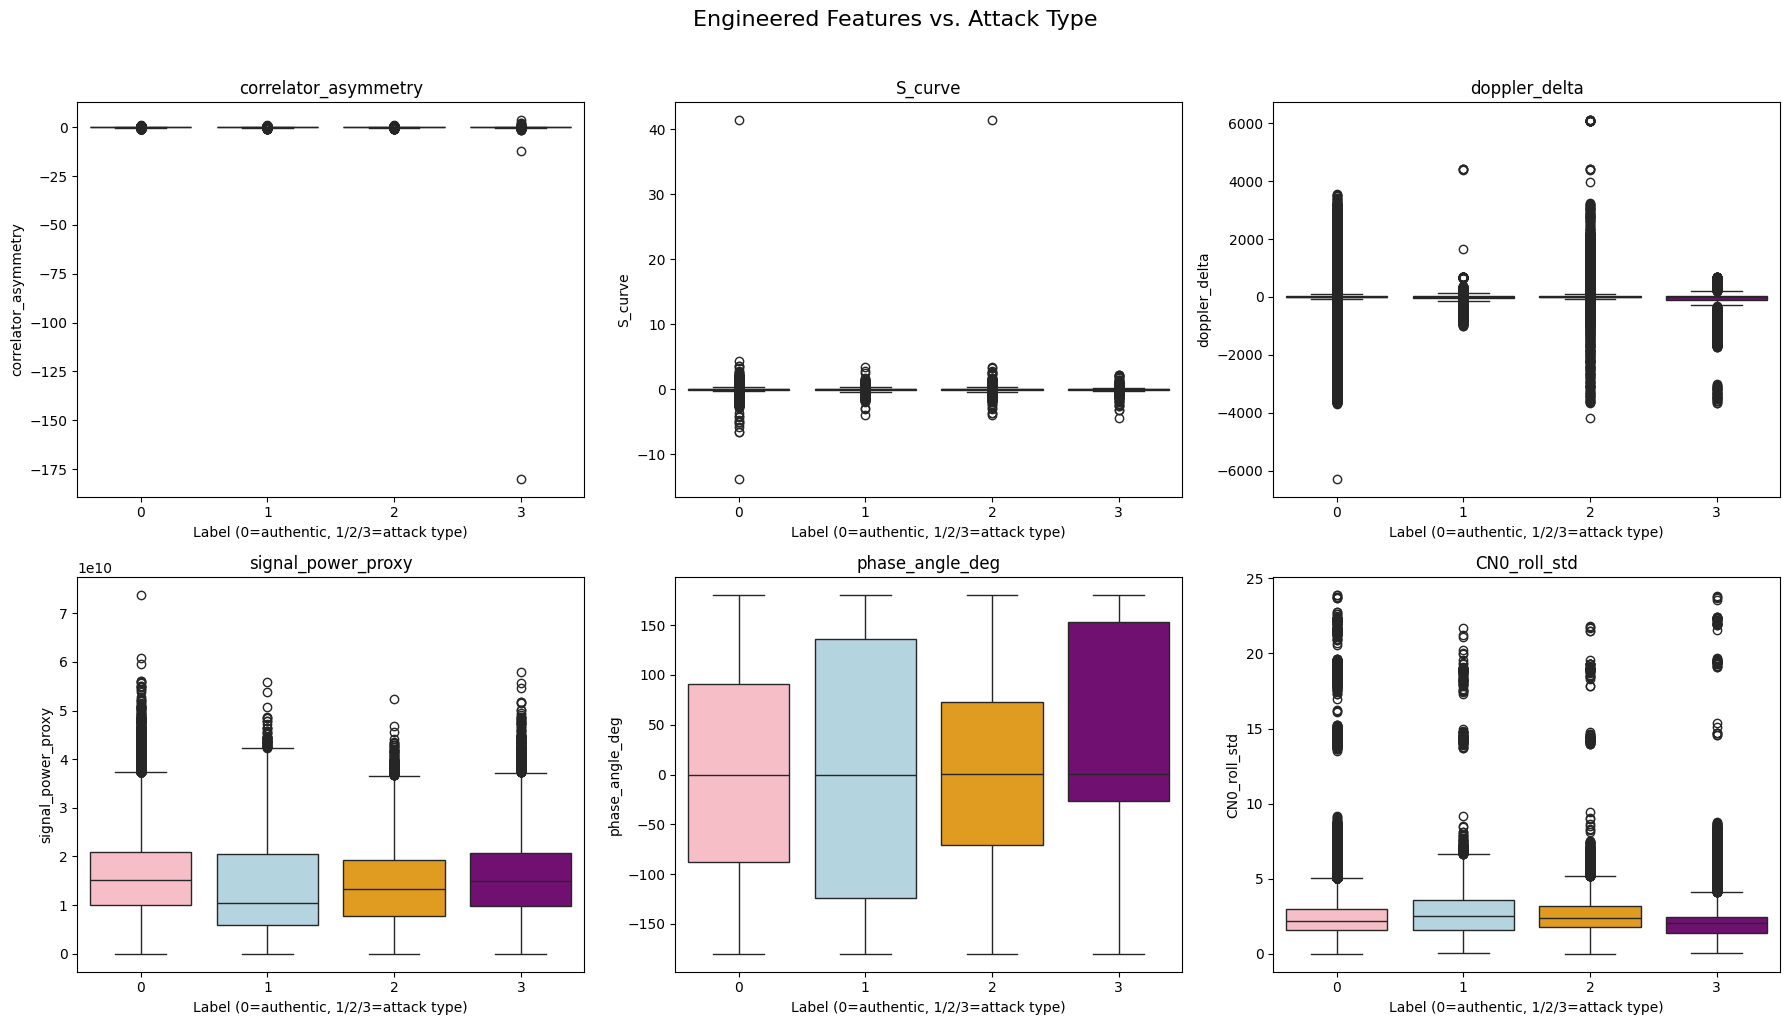

In [37]:
# new features viz
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

new_features = [
    "correlator_asymmetry", "S_curve", "doppler_delta",
    "signal_power_proxy",   "phase_angle_deg", "CN0_roll_std"
]

for ax, feat in zip(axes.flatten(), new_features):
    sns.boxplot(x="Output", y=feat, data=df, ax=ax,
                palette={'0': "lightpink", '1': "lightblue", '2': "orange", '3': "purple"})
    ax.set_title(feat, fontsize=12)
    ax.set_xlabel("Label (0=authentic, 1/2/3=attack type)")

plt.suptitle("Engineered Features vs. Attack Type", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

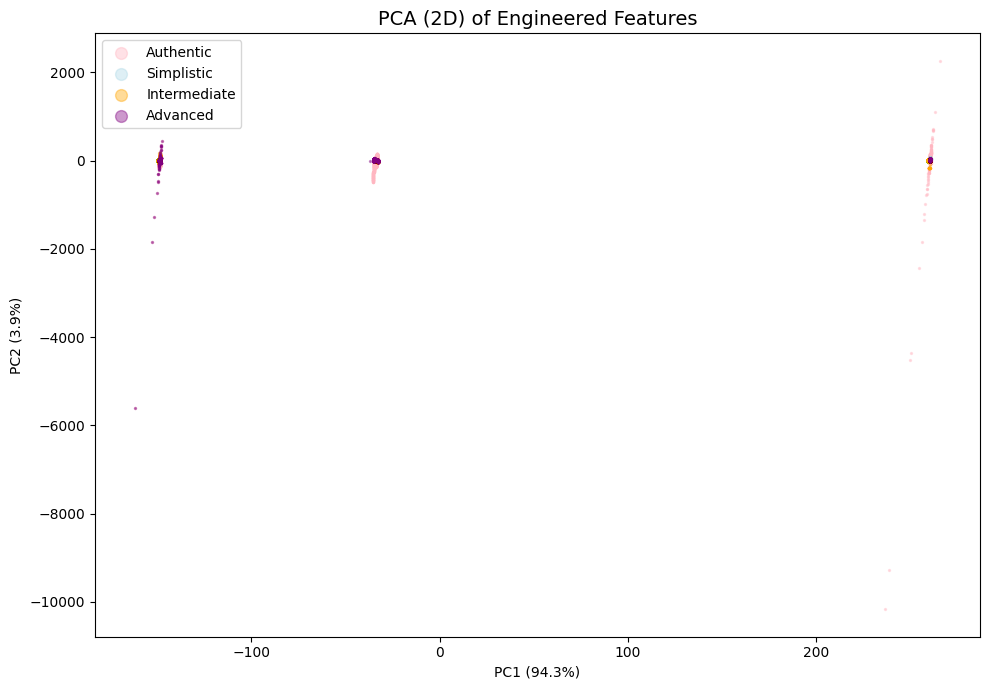

In [95]:
# feature importance using PCA

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
X = df_scaled[feature_cols].fillna(0).values
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(10, 7))
colors = {0: "lightpink", 1: "lightblue", 2: "orange", 3: "purple"}
labels_map = {0: "Authentic", 1: "Simplistic", 2: "Intermediate", 3: "Advanced"}

for label in [0, 1, 2, 3]:
    mask = df["Output"] == label
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=colors[label], label=labels_map[label],
                s=2, alpha=0.4)

plt.title("PCA (2D) of Engineered Features", fontsize=14)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.legend(markerscale=6)
plt.tight_layout()
plt.show()

In [39]:
# saving into kosciuszkon drive

df_fe_2d = df_scaled.copy()
print("df_fe_2d ready for ML/DL models.")
df_fe_2d.to_csv("ready_2d.csv")

df_fe_2d ready for ML/DL models.


In [40]:
# PART 2 - feature engineering for 3d dataset
"""
 3D -> Graph Construction for GNN

Input:  main_3d — shape with columns:
        [PRN, DO, PD, RX, TOW, CP, EC, LC, PC, PIP, PQP, TCD, CN0, Output]
        BUT loaded as flat 2D from Excel channels are encoded in row structure.

1. Grouping rows into time windows of W consecutive samples -> one graph per window
2. Each of the 8 channels = 1 node
3. Node features = 13 GNSS features + engineered features per channel
4. Edges = Pearson correlation between channels' CN0/EC/PC sequences in the window
5. Edge weight threshold θ to keep only meaningful correlations
6. Graph label = majority label in the window (or max-severity label)

Output: list of (node_feature_matrix, edge_index, edge_weight, graph_label)
"""

"\n 3D -> Graph Construction for GNN\n\nInput:  main_3d — shape with columns:\n        [PRN, DO, PD, RX, TOW, CP, EC, LC, PC, PIP, PQP, TCD, CN0, Output]\n        BUT loaded as flat 2D from Excel channels are encoded in row structure.\n\n1. Grouping rows into time windows of W consecutive samples -> one graph per window\n2. Each of the 8 channels = 1 node\n3. Node features = 13 GNSS features + engineered features per channel\n4. Edges = Pearson correlation between channels' CN0/EC/PC sequences in the window\n5. Edge weight threshold θ to keep only meaningful correlations\n6. Graph label = majority label in the window (or max-severity label)\n\nOutput: list of (node_feature_matrix, edge_index, edge_weight, graph_label)\n"

In [41]:
# 3d format
print("main_3d_shape", main_3d.shape)

main_3d_shape (158176, 112)


In [42]:
print(f"Duplicates: {main_3d.duplicated().sum()}")
main_3d_nodupp = main_3d.drop_duplicates().reset_index(drop=True)
print(f"After: {main_3d_nodupp.shape}")

Duplicates: 46863
After: (111313, 112)


In [43]:
print("main_3d columns:", main_3d_nodupp.columns.tolist())

main_3d columns: ['PRN', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Carrier_Doppler_hz', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Pseudorange_m', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'RX_time', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27', 'Unnamed: 28', 'Unnamed: 29', 'Unnamed: 30', 'Unnamed: 31', 'TOW_at_current_symbol_s', 'Unnamed: 33', 'Unnamed: 34', 'Unnamed: 35', 'Unnamed: 36', 'Unnamed: 37', 'Unnamed: 38', 'Unnamed: 39', 'Carrier_phase_cycles', 'Unnamed: 41', 'Unnamed: 42', 'Unnamed: 43', 'Unnamed: 44', 'Unnamed: 45', 'Unnamed: 46', 'Unnamed: 47', 'EC', 'Unnamed: 49', 'Unnamed: 50', 'Unnamed: 51', 'Unnamed: 52', 'Unnamed: 53', 'Unnamed: 54', 'Unnamed: 55', 'LC', 'Unnamed: 57', 'Unnamed: 58', 'Unnamed: 59', 'Unnamed: 60', 'Unnamed: 61', 'Unnamed: 62', 'Unnamed: 63', 'PC', 'Unnamed: 65', 'Unnamed:

In [46]:
# Kolumny pogrupowane blokami po 8:
#[0:8] -> PRN (indeksy 0-7)
#[8:16]  -> Carrier_Doppler (indeksy 8-15)
#[16:24] -> Pseudorange (indeksy 16-23)
#[24:32] -> RX_time (indeksy 24-31)
#[32:40] -> TOW (indeksy 32-39)
#[40:48] -> Carrier_phase (indeksy 40-47)
#[48:56] -> EC (indeksy 48-55)
#[56:64] -> LC (indeksy 56-63)
#[64:72] -> PC (indeksy 64-71)
#[72:80] -> PIP (indeksy 72-79)
#[80:88] -> PQP (indeksy 80-87)
#[88:96] -> TCD (indeksy 88-95)
#[96:104] -> CN0 (indeksy 96-103)
#[104:112]-> Output (indeksy 104-111)

FEATURE_NAMES = ["PRN", "DO", "PD", "RX", "TOW", "CP", "EC", "LC", "PC", "PIP", "PQP", "TCD", "CN0"]

FEATURE_START_INDICES = {
    "PRN": 0,
    "DO":  8,
    "PD":  16,
    "RX":  24,
    "TOW": 32,
    "CP":  40,
    "EC":  48,
    "LC":  56,
    "PC":  64,
    "PIP": 72,
    "PQP": 80,
    "TCD": 88,
    "CN0": 96,
}
OUTPUT_START = 104  # Output from 104

In [47]:
def parse_3d_wide_unnamed(df_3d):
    arr = df_3d.values  # (N, 112)
    N = len(arr)

    data_array = np.zeros((N, 8, 13), dtype=np.float32)

    for fi, feat in enumerate(FEATURE_NAMES):
        start = FEATURE_START_INDICES[feat]
        for ch in range(8):
            col_idx = start + ch
            data_array[:, ch, fi] = pd.to_numeric(df_3d.iloc[:, col_idx], errors='coerce').fillna(0).values
    labels = pd.to_numeric(
        df_3d.iloc[:, OUTPUT_START], errors='coerce'
    ).fillna(0).values.astype(int)

    return data_array, labels

In [51]:
print("\Parsing")
data_3d, labels_3d = parse_3d_wide_unnamed(main_3d_nodupp)

\Parsing


In [52]:
print(f"data_3d shape: {data_3d.shape}") # (N, 8, 13)
print(f"labels shape: {labels_3d.shape}")
print(f"Uniques labele:{np.unique(labels_3d)}")
print(f"Classes: {pd.Series(labels_3d).value_counts().sort_index().to_dict()}")

data_3d shape: (111313, 8, 13)
labels shape: (111313,)
Uniques labele:[0 1 2 3]
Classes: {0: 89160, 1: 2500, 2: 13653, 3: 6000}


In [96]:
print("\nWeryfikacja CH1 vs data_2d ierwsze 3 próbki:")
print("CH1 z 3D — CN0:", data_3d[:3, 0, 12])   # CN0 to index 12


Weryfikacja CH1 vs data_2d ierwsze 3 próbki:
CH1 z 3D — CN0: [49.41253  49.452686 49.480145]


In [62]:
row_sums = np.abs(data_3d).sum(axis=(1, 2))  # (N,)
nonzero_mask = row_sums > 0
FEATURE_NAMES = ["PRN","DO","PD","RX","TOW","CP","EC","LC","PC","PIP","PQP","TCD","CN0"]
N_CHANNELS = 8
data_3d_clean  = data_3d[nonzero_mask]
labels_3d_clean = labels_3d[nonzero_mask]

print(f"\nAfter cleaning :")
print(f" left {data_3d_clean.shape[0]:,} / {data_3d.shape[0]:,} próbek")
print(f"shape: {data_3d_clean.shape}")
print(f"Class dist: {pd.Series(labels_3d_clean).value_counts().sort_index().to_dict()}")

# Sanity check
sample_df = pd.DataFrame(
    data_3d_clean[0],
    columns=FEATURE_NAMES,
    index=[f"CH{i}" for i in range(N_CHANNELS)]
).round(3)


After cleaning :
 left 111,311 / 111,313 próbek
shape: (111311, 8, 13)
Class dist: {0: 89158, 1: 2500, 2: 13653, 3: 6000}


In [64]:
flat = data_3d_clean.reshape(len(data_3d_clean), -1)  # (N, 104)
flat_with_label = np.concatenate([flat, labels_3d_clean.reshape(-1,1)], axis=1)

df_flat = pd.DataFrame(flat_with_label)
df_flat_nodupp = df_flat.drop_duplicates().reset_index(drop=True)

data_3d = df_flat_nodupp.iloc[:, :-1].values.reshape(-1, N_CHANNELS, 13).astype(np.float32)
labels_3d = df_flat_nodupp.iloc[:, -1].values.astype(int)

print(f"\after deduplication: {data_3d.shape}")
print(f"Class dist: {pd.Series(labels_3d).value_counts().sort_index().to_dict()}")

fter deduplication: (110683, 8, 13)
Class dist: {0: 88530, 1: 2500, 2: 13653, 3: 6000}


In [65]:
FEAT = {"PRN":0,"DO":1,"PD":2,"RX":3,"TOW":4,"CP":5, "EC":6,"LC":7,"PC":8,"PIP":9,"PQP":10,"TCD":11,"CN0":12}

def engineer_channel_features(sample):
    """(8,13) to (8,22)"""
    s = sample.astype(np.float32)
    ec=s[:,FEAT["EC"]]; lc=s[:,FEAT["LC"]]; pc=s[:,FEAT["PC"]]
    pip=s[:,FEAT["PIP"]]; pqp=s[:,FEAT["PQP"]]
    do=s[:,FEAT["DO"]]; tcd=s[:,FEAT["TCD"]]
    cn0=s[:,FEAT["CN0"]]; cp=s[:,FEAT["CP"]]

    extra = np.stack([
        (ec-lc)/(ec+lc+1e-9), # correlator_asymmetry
        (ec-lc)/(pc+1e-9), # S_curve
        pc/(ec+lc+1e-9), # peak_ratio
        pip**2+pqp**2, # signal_power
        np.arctan2(pqp,pip), # phase_angle
        do-tcd, # doppler_delta
        cp%1, # cp_fractional
        cn0-cn0.mean(), # cn0_dev inter-channel
        pc-pc.mean(), # pc_dev inter-channel
    ], axis=1)  # (8,9)

    return np.concatenate([s, extra], axis=1)  # shoulb be(8,22)
print("\nEngineering node features...")
data_3d_fe = np.array([engineer_channel_features(s) for s in data_3d])
print(f"Enriched: {data_3d_fe.shape}")   # should be (N, 8, 22)


Engineering node features...
Enriched: (110683, 8, 22)


# ❤ graph building

In [76]:
WINDOW_SIZE = 20
STRIDE = 10
CORR_THRESHOLD = 0.1 # prev 0.3

In [86]:
def build_graph_from_window(window_data, window_labels):
    W, C, F = window_data.shape

    cn0_series = window_data[:, :, FEAT["CN0"]]  # (W, 8)

    active = (cn0_series.std(axis=0) > 1e-6).sum()
    if active < 3:
        return None
    # Node features
    node_mean = window_data.mean(axis=0)
    node_std = window_data.std(axis=0)
    node_min = window_data.min(axis=0)
    node_max = window_data.max(axis=0)
    key_idx = [FEAT["CN0"], FEAT["PC"], FEAT["DO"]]
    node_skew = np.array([[skew(window_data[:,ch,fi]) for fi in key_idx] for ch in range(C)])
    node_features = np.nan_to_num(
        np.concatenate([node_mean, node_std, node_min, node_max, node_skew], axis=1)
    ).astype(np.float32)

    srcs, dsts, wts = [], [], []
    for i in range(C):
        for j in range(i+1, C):
            si = cn0_series[:, i].std()
            sj = cn0_series[:, j].std()
            if si < 1e-6 or sj < 1e-6:
                w = 0.0
            else:
                corr = np.corrcoef(cn0_series[:, i], cn0_series[:, j])[0, 1]
                w = float(abs(corr)) if not np.isnan(corr) else 0.0
            srcs += [i, j]; dsts += [j, i]
            wts  += [w, w]

    unique, counts = np.unique(window_labels, return_counts=True)
    return (node_features,
            np.array([srcs, dsts], dtype=np.int64),
            np.array(wts, dtype=np.float32),
            int(unique[np.argmax(counts)]))


In [ ]:

print("Budowanie grafów...")
graphs = []
for s in range(0, len(data_3d_fe) - WINDOW_SIZE, STRIDE):
    g = build_graph_from_window(
        data_3d_fe[s:s+WINDOW_SIZE],
        labels_3d[s:s+WINDOW_SIZE]
    )
    if g is not None:
        graphs.append(g)

print(f"Graph amount after filtering: {len(graphs):,}")
print(f"Distribution: {pd.Series([g[3] for g in graphs]).value_counts().sort_index().to_dict()}")

Authentic: 48.66
Simplistic : 16.27
Intermediate : 52.01
Sophisticated: 25.27


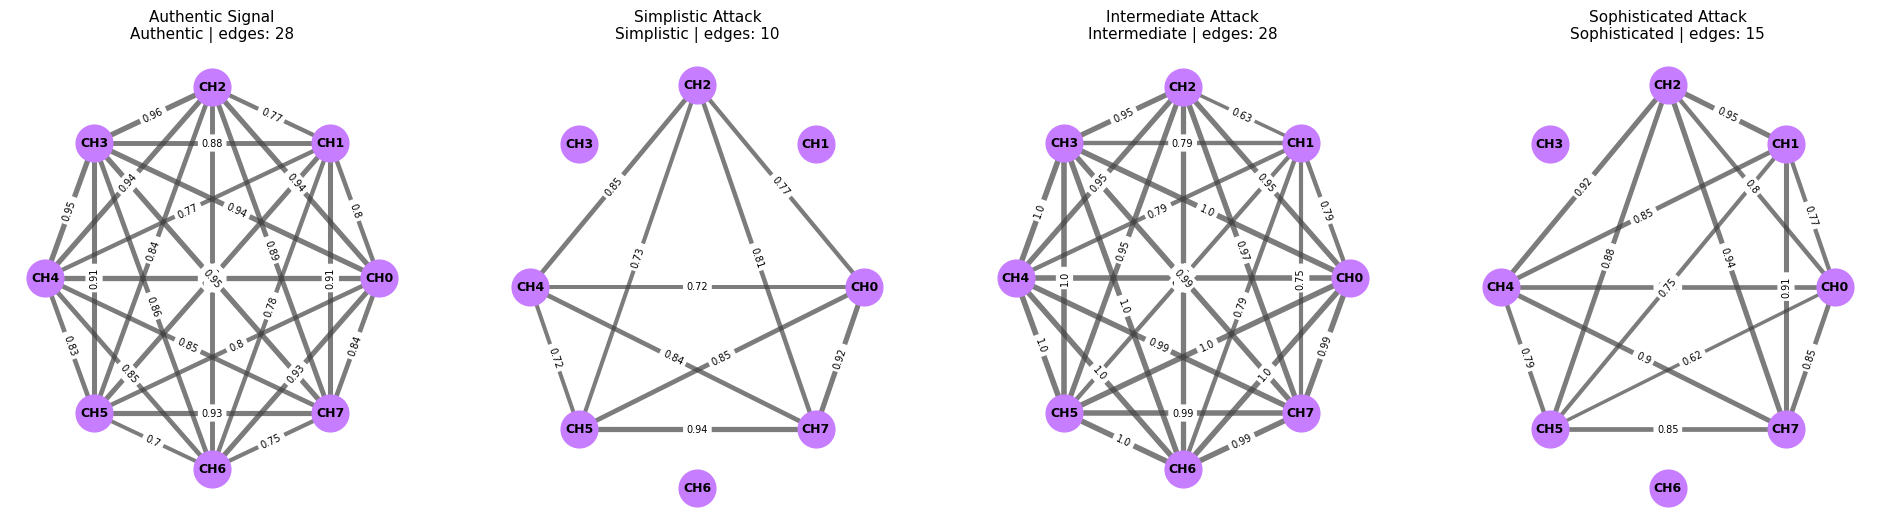

In [92]:
auth_graphs = [g for g in graphs if g[3] == 0]
simp_graphs = [g for g in graphs if g[3] == 1]
inter_graphs = [g for g in graphs if g[3] == 2]
soph_graphs = [g for g in graphs if g[3] == 3]

best_auth = max(auth_graphs,  key=lambda g: g[2].sum())
best_simp = max(simp_graphs,  key=lambda g: g[2].sum())
best_inter = max(inter_graphs, key=lambda g: g[2].sum())
best_soph = max(soph_graphs,  key=lambda g: g[2].sum())

print(f"Authentic: {best_auth[2].sum():.2f}")
print(f"Simplistic : {best_simp[2].sum():.2f}")
print(f"Intermediate : {best_inter[2].sum():.2f}")
print(f"Sophisticated: {best_soph[2].sum():.2f}")

fig, axes = plt.subplots(1, 4, figsize=(24, 6))

def plot_graph(graph, title, ax):
    nf, ei, ew, label = graph
    G = nx.Graph()
    G.add_nodes_from(range(N_CHANNELS))
    for i in range(0, ei.shape[1], 2):
        src, dst = int(ei[0,i]), int(ei[1,i])
        w = round(float(ew[i]), 2)
        if w > 0.0:
            G.add_edge(src, dst, weight=w)

    pos = nx.circular_layout(G)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color="#c77dff", node_size=700)
    nx.draw_networkx_labels(G, pos,
                            labels={i: f"CH{i}" for i in range(N_CHANNELS)},
                            ax=ax, font_size=9, font_weight="bold")
    if G.number_of_edges() > 0:
        nx.draw_networkx_edges(G, pos, ax=ax,
                               width=[G[u][v]['weight'] * 4 for u,v in G.edges()],
                               edge_color="#444", alpha=0.7)
        nx.draw_networkx_edge_labels(G, pos,
                                     edge_labels=nx.get_edge_attributes(G, 'weight'),
                                     ax=ax, font_size=7)
    names = {0:"Authentic", 1:"Simplistic", 2:"Intermediate", 3:"Sophisticated"}
    ax.set_title(f"{title}\n{names.get(label, label)} | edges: {G.number_of_edges()}", fontsize=11)
    ax.axis("off")

plot_graph(best_auth,"Authentic Signal", axes[0])
plot_graph(best_simp,"Simplistic Attack",axes[1])
plot_graph(best_inter,"Intermediate Attack", axes[2])
plot_graph(best_soph,"Sophisticated Attack",axes[3])


In [70]:
# !pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 814.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 6.8 MB/s eta 0:00:00


Authentic GNSS signals exhibit strong inter-channel correlation patterns, resulting in densely connected graph topologies.
Under spoofing attacks, graph connectivity becomes sparse and fragmented, indicating disruption of normal satellite-channel relationships.

The visualization illustrates the graph-based representation of GNSS satellite-channel interactions for authentic and spoofed GPS signals. Each node represents a satellite channel, while edge weights correspond to the temporal correlation of CN0 signal behavior between channels.

In the authentic signal graph, the topology is highly connected and structurally consistent. Most channels show strong pairwise correlations, with edge weights generally remaining high across the network. In contrast, the sophisticated spoofing attack graph shows noticeable structural degradation. Although the graph remains connected, multiple channel relationships weaken significantly, and several edges exhibit near-zero correlation values.

These observations support the hypothesis that GPS spoofing attacks not only affect individual signal measurements, but also disturb the relational structure between GNSS channels.

# ❤ ML Models

Models trained : <br>
-> Random Forest - baseline <br>
-> XGBoost - gradient boosting <br>
-> LightGBM - faster boosting <br>
-> SVM - baseline <br>
->MLP - neural network baseline <br>

Best model was tuned and saved.

Metrics used: Accuracy, F1, Confusion Matrix, Classification Report

In [98]:
# importings
import joblib
import os
import warnings
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score, roc_auc_score)
from sklearn.preprocessing import label_binarize
import xgboost as xgb
import lightgbm as lgb

In [99]:
# catalog for saving
MODELS_DIR = "/content/drive/MyDrive/kosciuszkon/models"
os.makedirs(MODELS_DIR, exist_ok=True)

In [100]:
# choosing the data
X = df_fe_2d.drop(columns=["Output"]).values.astype(np.float32) # getting rid of the labels
y = df_fe_2d['Output'].values.astype(int)

In [101]:
print(f"Dataset shape: {X.shape}")
print(f"Class distribution:\n{pd.Series(y).value_counts().sort_index()}")

# Stratified split — zachowuje rozkład klas
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

Dataset shape: (479312, 40)
Class distribution:
0    366608
1     36457
2     44232
3     32015
Name: count, dtype: int64

Train: (383449, 40), Test: (95863, 40)


In [103]:
# utils
LABEL_NAMES = {0: "Authentic", 1: "Simplistic", 2: "Intermediate", 3: "Sophisticated"}

def evaluate_model(model, X_test, y_test, model_name):
  y_pred = model.predict(X_test)
  acc = accuracy_score(y_test, y_pred)
  f1_macro = f1_score(y_test, y_pred, average="macro")
  f1_weighted = f1_score(y_test, y_pred, average="weighted")

  print(f"{model_name}")
  print(f"Accuracy for: {acc:.3f}")
  print(f"F1 macro: {f1_macro:.3f} ")
  print(f"f1 weighted: {f1_weighted:.3f}")
  print(f"\n{classification_report(y_test, y_pred, target_names=list(LABEL_NAMES.values()))}")

  # confusion matrix
  cm = confusion_matrix(y_test, y_pred)
  fig, ax = plt.subplots(figsize=(7,5))
  sns.heatmap(cm, annot=True, fmt="d", cmap="PuRd", xticklabels=list(LABEL_NAMES.values()), yticklabels=list(LABEL_NAMES.values()), ax=ax)
  ax.set_title(f"{model_name} — Confusion Matrix", fontsize=13)
  ax.set_ylabel("True label")
  ax.set_xlabel("Predicted label")
  plt.tight_layout()
  plt.show()

  return {"model": model_name, "accuracy": acc, "f1_macro": f1_macro, "f1_weighted": f1_weighted}

In [104]:
def save_model(model, name):
  path = os.path.join(MODELS_DIR, f"{name}.pkl")
  joblib.dump(model,path)
  print(f"Model saved: {path}")

Random Forest

Random Forest is a great baseline model often used for anomaly detection as it really is a strong choice for datasets with many outliers. Our data is nonlinear - it contains multiple signal - derived attributes, temporal statistics, spoofing and simpler linear models often times cannot effectively capture.

Additionally, Random Forest is robust to noise measurements and varying feature distributions. Since the model operates through an ensemble of decision trees, it can learn complex decision boundaries without requiring extensive feature scaling or strict distribution assumptions.

Another important advantage of Random Forest is its interpretability through feature importance analysis.

Furthermore, Random Forest serves as a strong classical machine learning baseline for comparison with more advanced approaches, including Graph Neural Networks (GNNs) and temporal deep learning models which will be truly useful for us in the future.

Random Forest
Accuracy for: 0.940
F1 macro: 0.896 
f1 weighted: 0.943

               precision    recall  f1-score   support

    Authentic       1.00      0.94      0.97     73322
   Simplistic       0.79      0.93      0.85      7291
 Intermediate       0.72      0.92      0.81      8847
Sophisticated       0.92      1.00      0.96      6403

     accuracy                           0.94     95863
    macro avg       0.86      0.95      0.90     95863
 weighted avg       0.95      0.94      0.94     95863



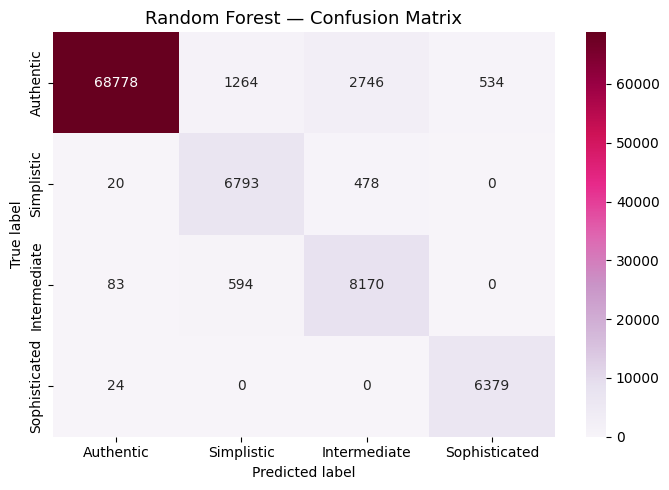

Model saved: /content/drive/MyDrive/kosciuszkon/models/random_forest.pkl


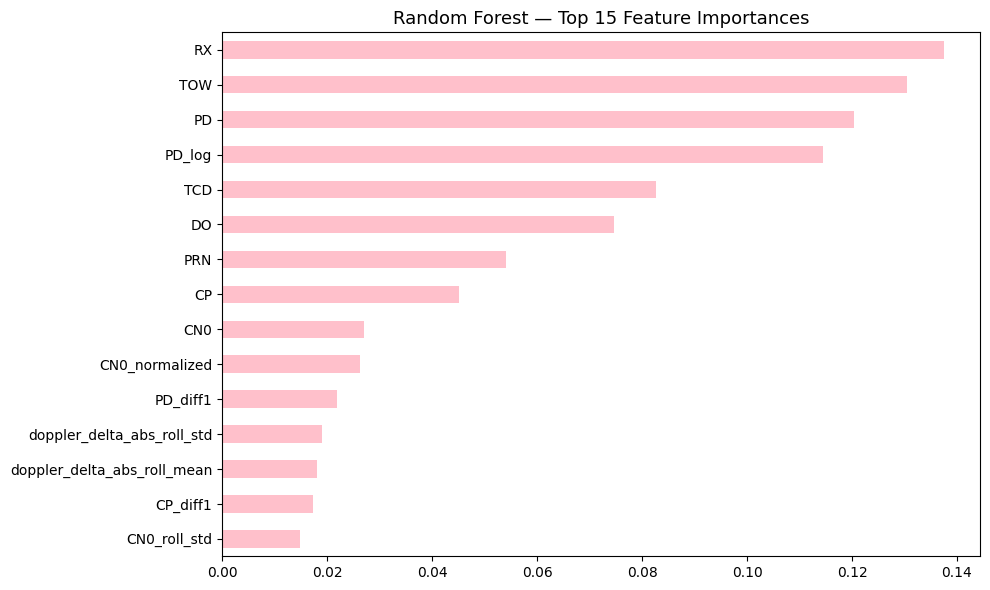

In [121]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# eval
rf_results = evaluate_model(rf_model, X_test, y_test, "Random Forest")
save_model(rf_model, "random_forest")

# feature importance
feat_names = df_fe_2d.drop(columns=["Output"]).columns.tolist()

fi = pd.Series(
    rf_model.feature_importances_,
    index=feat_names
).nlargest(15)

plt.figure(figsize=(10, 6))
fi.sort_values().plot(kind="barh", color="pink")
plt.title("Random Forest — Top 15 Feature Importances", fontsize=13)
plt.tight_layout()
plt.show()

< there will be results >

---

XGBoost
XGBoost was selected because it is highly effective for structured and engineered tabular data with complex nonlinear relationships. The model is particularly well-suited for GNSS spoofing detection where subtle interactions between signal characteristics, temporal statistics, and anomaly-related features must be captured.

Additionally, XGBoost provides strong predictive performance, robustness to noisy data (outliers), and feature importance analysis, making it an excellent baseline model for comparison with GNN models in the future.

Training quick XGBoost model

[0]	validation_0-mlogloss:0.71778	validation_1-mlogloss:0.71841
[1]	validation_0-mlogloss:0.64419	validation_1-mlogloss:0.64467
[2]	validation_0-mlogloss:0.59025	validation_1-mlogloss:0.59059
[3]	validation_0-mlogloss:0.54351	validation_1-mlogloss:0.54417
[4]	validation_0-mlogloss:0.50901	validation_1-mlogloss:0.50969
[5]	validation_0-mlogloss:0.48042	validation_1-mlogloss:0.48108
[6]	validation_0-mlogloss:0.45473	validation_1-mlogloss:0.45539
[7]	validation_0-mlogloss:0.42789	validation_1-mlogloss:0.42861
[8]	validation_0-mlogloss:0.40763	validation_1-mlogloss:0.40836
[9]	validation_0-mlogloss:0.38840	validation_1-mlogloss:0.38912
[10]	validation_0-mlogloss:0.36962	validation_1-mlogloss:0.37038
[11]	validation_0-mlogloss:0.35091	validation_1-mlogloss:0.35176
[12]	validation_0-mlogloss:0.33388	validation_1-mlogloss:0.33473
[13]	validation_0-mlogloss:0.31895	validation_1-mlogloss:0.31981
[14]	validation_0-mlogloss:0.30469	validation_1-mlogloss:0.30559
[15]	

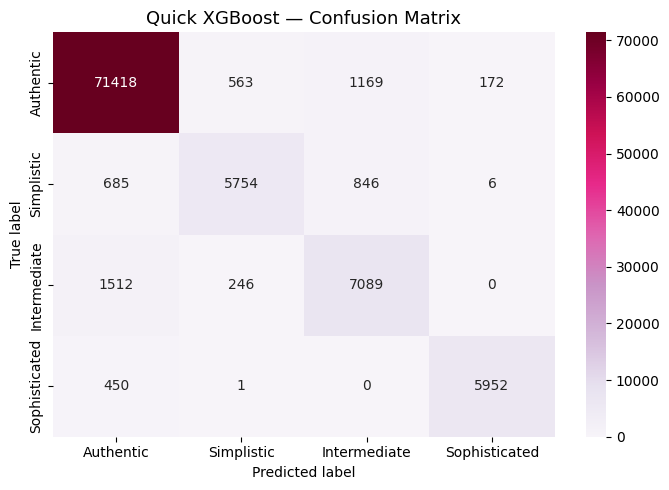

Model saved: /content/drive/MyDrive/kosciuszkon/models/quick_xgboost.pkl


In [120]:
quick_xgb = xgb.XGBClassifier(
    objective="multi:softmax", num_class=4, eval_metric="mlogloss", random_state=42, n_estimators=100,
    max_depth=5, learning_rate=0.1,subsample=0.8,colsample_bytree=0.8,
    tree_method="hist",
    n_jobs=-1,
    verbosity=1
)

print("Training quick XGBoost model\n")

quick_xgb.fit(
    X_train,
    y_train,
    eval_set=[
        (X_train, y_train),
        (X_test, y_test)
    ],
    verbose=True
)

print("\nTraining finished.")

# evaluation
xgb_results = evaluate_model(
    quick_xgb,
    X_test,
    y_test,
    "Quick XGBoost"
)

save_model(
    quick_xgb,
    "quick_xgboost"
)

---
XGBoost was selected since it is highly effective for for structured and engineered tabular data with many nonlinear relationships. Model is capable of learning subtle interactions and spoofing-related anomalies. Additionally, XGBoost provides strong predictive performance while using gradient boosting.


---

Training LightGBM model...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.705814 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9963
[LightGBM] [Info] Number of data points in the train set: 383449, number of used features: 40
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
Training finished.
LightGBM
Accuracy for: 0.941
F1 macro: 0.897 
f1 weighted: 0.944

               precision    recall  f1-score   support

    Authentic       1.00      0.94      0.97     73322
   Simplistic       0.79      0.93      0.85      7291
 Intermediate       0.72      0.93      0.81      8847
Sophisticated       0.92      0.99      0.96      6403

     accuracy                           0.94     95863
    macro avg       0.86      0.95      0.90     9

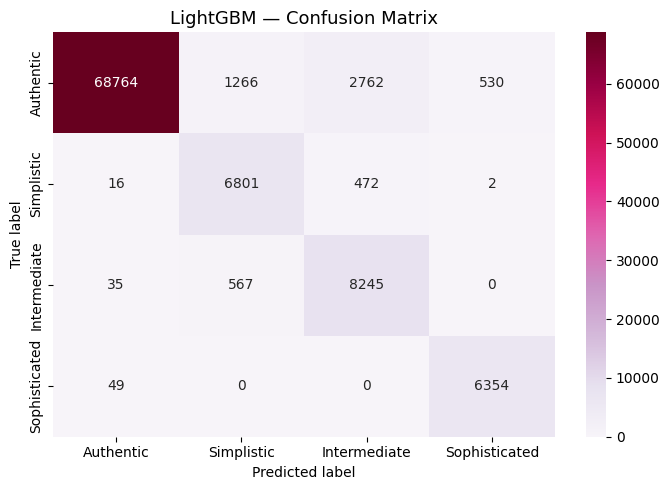

Model saved: /content/drive/MyDrive/kosciuszkon/models/quick_lightgbm.pkl


In [114]:
from lightgbm import LGBMClassifier

quick_lgb = LGBMClassifier(
    objective="multiclass",
    num_class=4,
    n_estimators=200,
    max_depth=10,
    learning_rate=0.1,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Training LightGBM model")

quick_lgb.fit(X_train, y_train)

print("Training finished.")

lgb_results = evaluate_model(
    quick_lgb,
    X_test,
    y_test,
    "LightGBM"
)

save_model(
    quick_lgb,
    "quick_lightgbm"
)

---
Support Vector Machines were selected because they are effective for high-dimensional classification problems and can model complex decision boundaries through kernel-based learning. They are also popular in Cybersecurity fields and anomaly detections.
However they are heavily source consuming so we decided to use them as proof of concept using only 20k data sample.

Training SVM model
  SVM train size: (20000, 40)
Training finished.
SVM
Accuracy for: 0.572
F1 macro: 0.479 
f1 weighted: 0.618

               precision    recall  f1-score   support

    Authentic       0.95      0.53      0.68     73322
   Simplistic       0.28      0.85      0.42      7291
 Intermediate       0.38      0.47      0.42      8847
Sophisticated       0.26      0.87      0.40      6403

     accuracy                           0.57     95863
    macro avg       0.47      0.68      0.48     95863
 weighted avg       0.80      0.57      0.62     95863



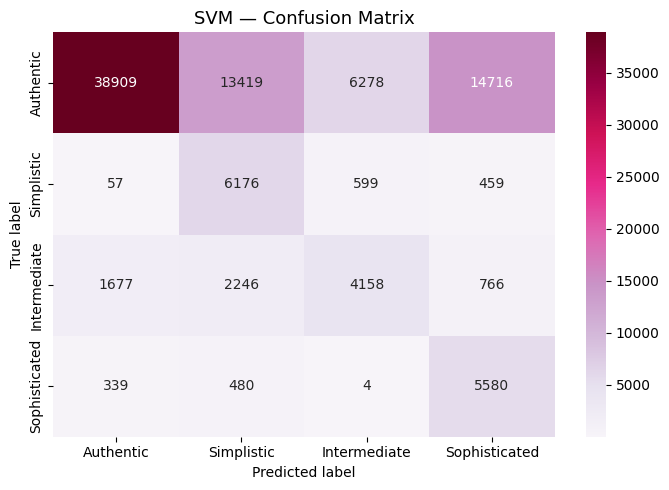

Model saved: /content/drive/MyDrive/kosciuszkon/models/quick_svm.pkl


In [118]:
from sklearn.svm import SVC

quick_svm = SVC(
    kernel="rbf",
    C=10,
    gamma="scale",
    class_weight="balanced",
    probability=True,
    random_state=42
)

print("Training SVM model")

sample_idx = []
for cls in [0, 1, 2, 3]:
    cls_idx = np.where(y_train == cls)[0]
    n = min(5000, len(cls_idx))
    sample_idx.extend(np.random.choice(cls_idx, n, replace=False))

X_svm = X_train[sample_idx]
y_svm = y_train[sample_idx]
print(f"  SVM train size: {X_svm.shape}")

quick_svm.fit(X_svm, y_svm)

print("Training finished.")

svm_results = evaluate_model(
    quick_svm,
    X_test,
    y_test,
    "SVM"
)

save_model(
    quick_svm,
    "quick_svm"
)

---
Multi-Layer Perceptron was chosen to evaluate the effectiveness of deep neural networks on engineered GNSS features. Unlike traditional machine learning models, MLPs can learn hierarchical nonlinear feature representations and complex interactions between signal characteristics and this makes them suitable for detecting spoofing patterns that may not be captured by simpler models. Additionally, the MLP serves as a bridge between classical machine learning approaches and more advanced graph-based deep learning models.


\ MLP — tuning
Training MLP model...
Training finished.
MLP
Accuracy for: 0.933
F1 macro: 0.861 
f1 weighted: 0.930

               precision    recall  f1-score   support

    Authentic       0.95      0.98      0.97     73322
   Simplistic       0.85      0.78      0.81      7291
 Intermediate       0.82      0.64      0.72      8847
Sophisticated       0.93      0.96      0.95      6403

     accuracy                           0.93     95863
    macro avg       0.89      0.84      0.86     95863
 weighted avg       0.93      0.93      0.93     95863



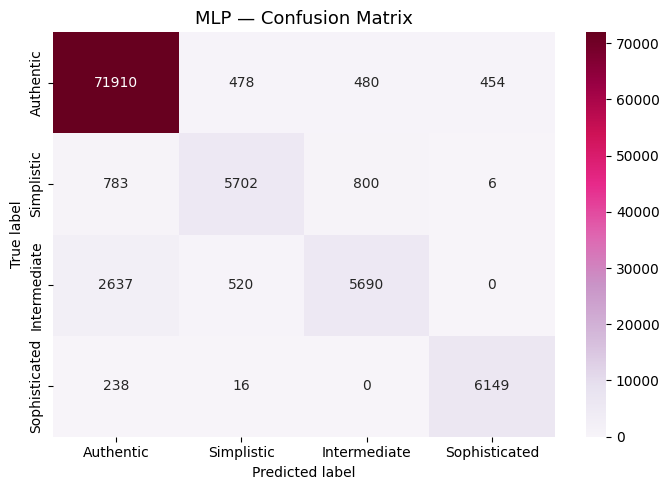

Model saved: /content/drive/MyDrive/kosciuszkon/models/quick_mlp.pkl


In [119]:
print("\ MLP — tuning")
from sklearn.neural_network import MLPClassifier

print("Training MLP model...")

quick_mlp = MLPClassifier(
    hidden_layer_sizes=(256, 128),
    activation="relu",
    learning_rate_init=0.001,
    alpha=0.0001,
    batch_size=512,
    max_iter=100,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)

quick_mlp.fit(X_train, y_train)

print("Training finished.")

mlp_results = evaluate_model(
    quick_mlp,
    X_test,
    y_test,
    "MLP"
)

save_model(
    quick_mlp,
    "quick_mlp"
)

               accuracy  f1_macro  f1_weighted
model                                         
LightGBM         0.9406    0.8972       0.9435
Random Forest    0.9401    0.8962       0.9431
Quick XGBoost    0.9411    0.8848       0.9407
MLP              0.9331    0.8612       0.9303
SVM              0.5719    0.4789       0.6177


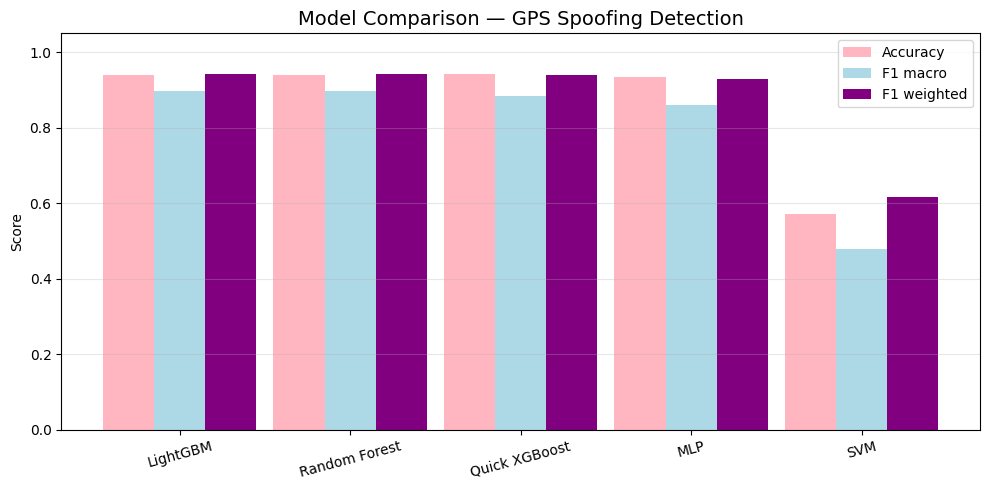

Results and models saved 


In [123]:

results_df = pd.DataFrame([
    rf_results, xgb_results, lgb_results, svm_results, mlp_results
]).set_index("model").sort_values("f1_macro", ascending=False)

print(results_df.round(4).to_string())

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(results_df))
w = 0.3

ax.bar(x - w, results_df["accuracy"], width=w, label="Accuracy", color="lightpink")
ax.bar(x, results_df["f1_macro"], width=w, label="F1 macro", color="lightblue")
ax.bar(x + w, results_df["f1_weighted"], width=w, label="F1 weighted", color="purple")

ax.set_xticks(x)
ax.set_xticklabels(results_df.index, rotation=15)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Model Comparison — GPS Spoofing Detection", fontsize=14)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

results_df.to_csv(os.path.join(MODELS_DIR, "ml_results_summary.csv"))
print("Results and models saved ")

# ❤ GNN - graph neural networks

In [124]:
# !pip install torch torch_geometric

In [148]:
# imports
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data, DataLoader
from torch_geometric.nn import (GCNConv, SAGEConv, GATConv, global_mean_pool, global_max_pool, global_add_pool)
from torch_geometric.nn import GAE, InnerProductDecoder
from torch_geometric.utils import negative_sampling
import torch
from sklearn.manifold import TSNE

In [129]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

MODELS_DIR = "/content/drive/MyDrive/kosciuszkon/models"
os.makedirs(MODELS_DIR, exist_ok=True)

Device: cpu


In [130]:
# cohesive colors
CLASS_COLORS = {0: "lightpink", 1: "lightblue", 2: "purple", 3: "orange"}
CLASS_NAMES  = {0: "Authentic", 1: "Simplistic", 2: "Intermediate", 3: "Sophisticated"}

In [133]:
def graphs_to_pyg(graphs):
    pyg_list = []
    for nf, ei, ew, label in graphs:
        data = Data(
            x = torch.tensor(nf, dtype=torch.float),
            edge_index = torch.tensor(ei, dtype=torch.long),
            edge_attr = torch.tensor(ew, dtype=torch.float).unsqueeze(1),
            y = torch.tensor([label], dtype=torch.long)
        )
        pyg_list.append(data)
    return pyg_list

pyg_all = graphs_to_pyg(graphs)
labels_all = [g.y.item() for g in pyg_all]

In [134]:
# stratified splitting
idx = list(range(len(pyg_all)))
idx_train, idx_test = train_test_split(idx, test_size=0.2, stratify=labels_all, random_state=42)
idx_train, idx_val  = train_test_split(idx_train, test_size=0.1, stratify=[labels_all[i] for i in idx_train], random_state=42)

train_loader = DataLoader([pyg_all[i] for i in idx_train], batch_size=64, shuffle=True)
val_loader = DataLoader([pyg_all[i] for i in idx_val],   batch_size=64, shuffle=False)
test_loader = DataLoader([pyg_all[i] for i in idx_test],  batch_size=64, shuffle=False)

IN_FEATURES = pyg_all[0].x.shape[1]
N_CLASSES   = 4
print(f"Graphs — train: {len(idx_train)}, val: {len(idx_val)}, test: {len(idx_test)}")
print(f"Node feature size: {IN_FEATURES}")

Graphs — train: 6602, val: 734, test: 1834
Node feature size: 91


In [135]:
# utils - train/eval/visual
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for batch in loader:
        batch = batch.to(DEVICE)
        optimizer.zero_grad()
        out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
        loss = criterion(out, batch.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
        correct += (out.argmax(dim=1) == batch.y).sum().item()
        total += batch.num_graphs
    return total_loss / total, correct / total

In [136]:
@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    for batch in loader:
        batch = batch.to(DEVICE)
        out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
        loss = criterion(out, batch.y)
        total_loss += loss.item() * batch.num_graphs
        correct += (out.argmax(dim=1) == batch.y).sum().item()
        total += batch.num_graphs
    return total_loss / total, correct / total

In [137]:
@torch.no_grad()
def get_predictions(model, loader):
    model.eval()
    all_preds, all_labels, all_embeds = [], [], []
    for batch in loader:
        batch = batch.to(DEVICE)
        out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
        all_preds.extend(out.argmax(dim=1).cpu().numpy())
        all_labels.extend(batch.y.cpu().numpy())
        all_embeds.extend(out.cpu().numpy())
    return np.array(all_preds), np.array(all_labels), np.array(all_embeds)


In [138]:
def train_model(model, name, epochs=50, lr=0.001):
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_acc, best_state = 0, None

    for epoch in range(1, epochs+1):
        tl, ta = train_epoch(model, train_loader, optimizer, criterion)
        vl, va = eval_epoch(model,  val_loader,   criterion)
        scheduler.step()

        history["train_loss"].append(tl)
        history["val_loss"].append(vl)
        history["train_acc"].append(ta)
        history["val_acc"].append(va)

        if va > best_val_acc:
            best_val_acc = va
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        if epoch % 10 == 0:
            print(f"  [{name}] Epoch {epoch:3d} | "
                  f"Train loss: {tl:.4f} acc: {ta:.4f} | "
                  f"Val loss: {vl:.4f} acc: {va:.4f}")

    # Load best
    model.load_state_dict(best_state)
    torch.save(best_state, os.path.join(MODELS_DIR, f"{name}_best.pt"))
    print(f"Saved: {name}_best.pt (best val acc: {best_val_acc:.3f})")
    return model, history

In [141]:
def plot_training(history, name):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.patch.set_facecolor("#0d0d0d")
    for ax in axes:
        ax.set_facecolor("#1a1a2e")
        ax.tick_params(colors="white")
        ax.xaxis.label.set_color("white")
        ax.yaxis.label.set_color("white")
        ax.title.set_color("white")
        for spine in ax.spines.values():
            spine.set_edgecolor("#444")

    epochs = range(1, len(history["train_loss"])+1)

    axes[0].plot(epochs, history["train_loss"], color="#c77dff", lw=2, label="Train")
    axes[0].plot(epochs, history["val_loss"], color="#ff9a8b", lw=2, label="Val", linestyle="--")
    axes[0].set_title(f"{name} — Loss", fontsize=12)
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
    axes[0].legend(facecolor="#1a1a2e", labelcolor="white")
    axes[0].grid(alpha=0.2)

    axes[1].plot(epochs, history["train_acc"], color="#c77dff", lw=2, label="Train")
    axes[1].plot(epochs, history["val_acc"], color="#ff9a8b", lw=2, label="Val", linestyle="--")
    axes[1].set_title(f"{name} — Accuracy", fontsize=12)
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
    axes[1].legend(facecolor="#1a1a2e", labelcolor="white")
    axes[1].grid(alpha=0.2)

    plt.suptitle(f"{name} — Training Curves", color="white", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

In [142]:
def plot_confusion(preds, labels, name):
    cm = confusion_matrix(labels, preds)
    fig, ax = plt.subplots(figsize=(7, 5))
    fig.patch.set_facecolor("#0d0d0d")
    ax.set_facecolor("#1a1a2e")
    sns.heatmap(cm, annot=True, fmt="d", cmap="RdPu", xticklabels=list(CLASS_NAMES.values()), yticklabels=list(CLASS_NAMES.values()), ax=ax, linewidths=0.5, linecolor="#444")
    ax.set_title(f"{name} — Confusion Matrix", color="white", fontsize=13)
    ax.set_ylabel("True", color="white")
    ax.set_xlabel("Predicted", color="white")
    ax.tick_params(colors="white")
    plt.tight_layout()
    plt.show()

In [143]:
def plot_tsne(embeds, labels, name):
    print(f"  Computing t-SNE for {name}...")
    sample = min(2000, len(embeds))
    idx = np.random.choice(len(embeds), sample, replace=False)
    e2d = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(embeds[idx])
    fig, ax = plt.subplots(figsize=(9, 7))
    fig.patch.set_facecolor("#0d0d0d")
    ax.set_facecolor("#1a1a2e")
    for cls in range(N_CLASSES):
        mask = labels[idx] == cls
        ax.scatter(e2d[mask, 0], e2d[mask, 1], c=CLASS_COLORS[cls], label=CLASS_NAMES[cls], s=12, alpha=0.7, edgecolors="none")
    ax.set_title(f"{name} — t-SNE Embeddings", color="white", fontsize=13)
    ax.tick_params(colors="white")
    legend = ax.legend(facecolor="#1a1a2e", labelcolor="white", markerscale=3)
    ax.grid(alpha=0.15)
    plt.tight_layout()
    plt.show()

In [146]:
def full_eval(model, name, history):
    preds, labels, embeds = get_predictions(model, test_loader)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average="macro")
    print(f"{name} — TEST RESULTS")
    print(f"Accuracy: {acc:.3f}")
    print(f"F1 macro: {f1:.3f}")
    print(f"\n{classification_report(labels, preds, target_names=list(CLASS_NAMES.values()))}")
    plot_training(history, name)
    plot_confusion(preds, labels, name)
    plot_tsne(embeds, labels, name)
    return {"model": name, "accuracy": acc, "f1_macro": f1}

Baseline Model - GCN

1. GCN — Graph Convolutional Network
  [GCN] Epoch  10 | Train loss: 0.6420 acc: 0.7573 | Val loss: 0.6098 acc: 0.7561
  [GCN] Epoch  20 | Train loss: 0.5948 acc: 0.7604 | Val loss: 0.5840 acc: 0.7629
  [GCN] Epoch  30 | Train loss: 0.5686 acc: 0.7616 | Val loss: 0.5332 acc: 0.7589
  [GCN] Epoch  40 | Train loss: 0.5524 acc: 0.7631 | Val loss: 0.5209 acc: 0.7698
  [GCN] Epoch  50 | Train loss: 0.5375 acc: 0.7679 | Val loss: 0.4996 acc: 0.7657
Saved: GCN_best.pt (best val acc: 0.771)
GCN — TEST RESULTS
Accuracy: 0.767
F1 macro: 0.265

               precision    recall  f1-score   support

    Authentic       0.77      0.99      0.87      1391
   Simplistic       0.00      0.00      0.00        50
 Intermediate       0.67      0.10      0.18       273
Sophisticated       0.33      0.01      0.02       120

     accuracy                           0.77      1834
    macro avg       0.44      0.28      0.27      1834
 weighted avg       0.70      0.77      0.68      1834



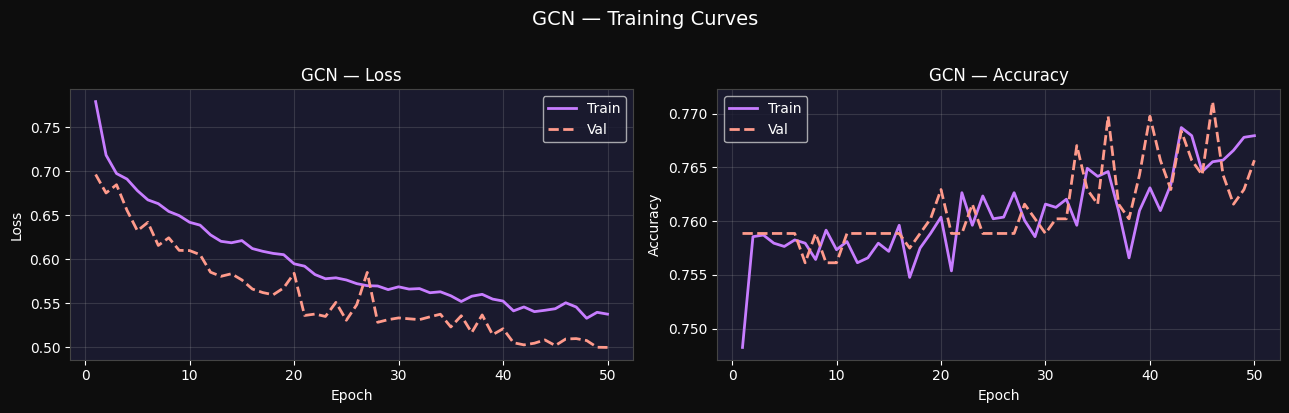

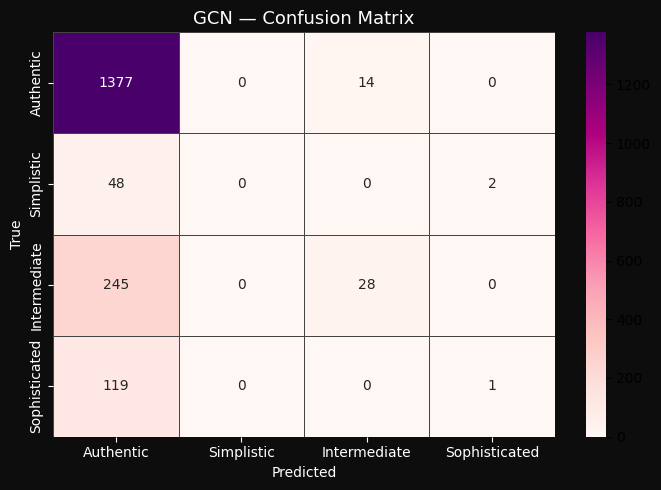

  Computing t-SNE for GCN...


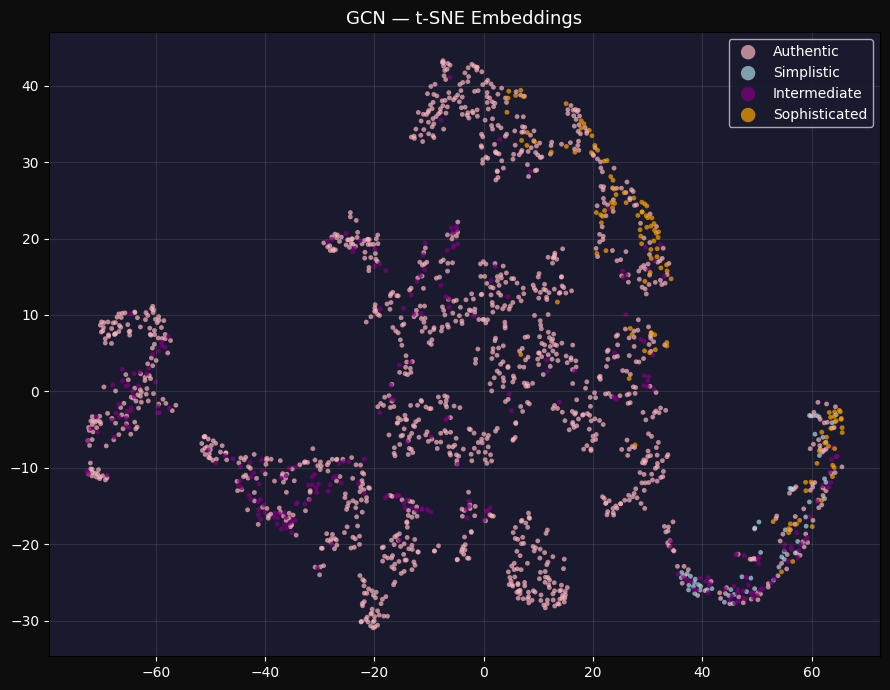

In [149]:
class GCN(nn.Module):
    def __init__(self, in_f=IN_FEATURES, hidden=128, out=N_CLASSES):
        super().__init__()
        self.conv1 = GCNConv(in_f, hidden)
        self.conv2 = GCNConv(hidden, hidden)
        self.conv3 = GCNConv(hidden, 64)
        self.bn1 = nn.BatchNorm1d(hidden)
        self.bn2 = nn.BatchNorm1d(hidden)
        self.bn3 = nn.BatchNorm1d(64)
        self.classifier = nn.Sequential(nn.Linear(64 * 2, 64), nn.ReLU(), nn.Dropout(0.3),nn.Linear(64, out)
        )

    def forward(self, x, edge_index, edge_attr, batch):
        ew = edge_attr.squeeze(-1) if edge_attr is not None else None
        x = F.relu(self.bn1(self.conv1(x, edge_index, ew)))
        x = F.dropout(x, p=0.3, training=self.training)
        x = F.relu(self.bn2(self.conv2(x, edge_index, ew)))
        x = F.relu(self.bn3(self.conv3(x, edge_index, ew)))
        x = torch.cat([global_mean_pool(x, batch), global_max_pool(x, batch)], dim=1)
        return self.classifier(x)

print("1. GCN — Graph Convolutional Network")

gcn_model, gcn_history = train_model(GCN(), "GCN", epochs=50)
gcn_results = full_eval(gcn_model, "GCN", gcn_history)

GraphSage

2. GraphSAGE
  [GraphSAGE] Epoch  10 | Train loss: 0.4902 acc: 0.7845 | Val loss: 0.4761 acc: 0.8120
  [GraphSAGE] Epoch  20 | Train loss: 0.4228 acc: 0.8087 | Val loss: 0.3758 acc: 0.8215
  [GraphSAGE] Epoch  30 | Train loss: 0.3736 acc: 0.8276 | Val loss: 0.3287 acc: 0.8392
  [GraphSAGE] Epoch  40 | Train loss: 0.3481 acc: 0.8344 | Val loss: 0.3073 acc: 0.8542
  [GraphSAGE] Epoch  50 | Train loss: 0.3240 acc: 0.8438 | Val loss: 0.3042 acc: 0.8433
Saved: GraphSAGE_best.pt (best val acc: 0.856)
GraphSAGE — TEST RESULTS
Accuracy: 0.862
F1 macro: 0.720

               precision    recall  f1-score   support

    Authentic       0.92      0.93      0.92      1391
   Simplistic       0.45      0.68      0.54        50
 Intermediate       0.72      0.59      0.65       273
Sophisticated       0.73      0.80      0.76       120

     accuracy                           0.86      1834
    macro avg       0.71      0.75      0.72      1834
 weighted avg       0.86      0.86      0.86      1834


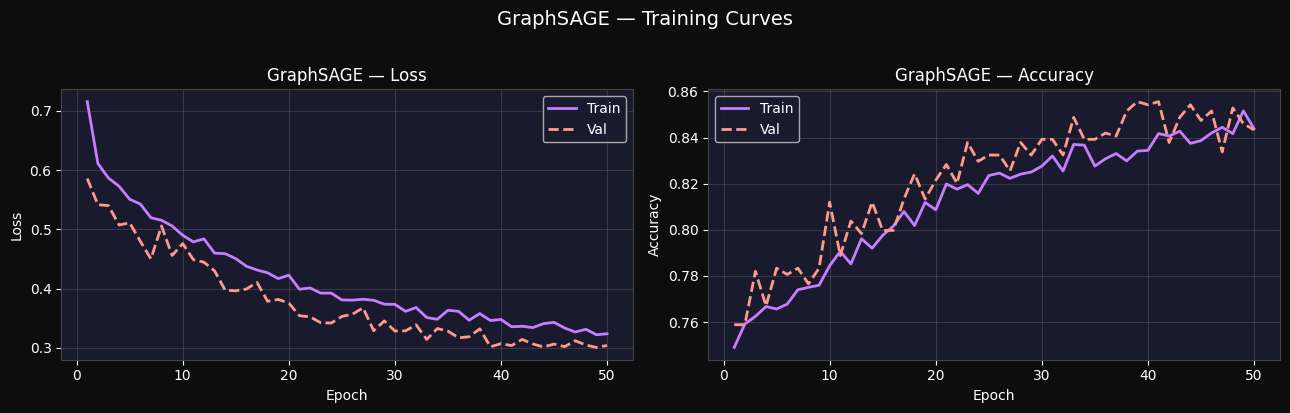

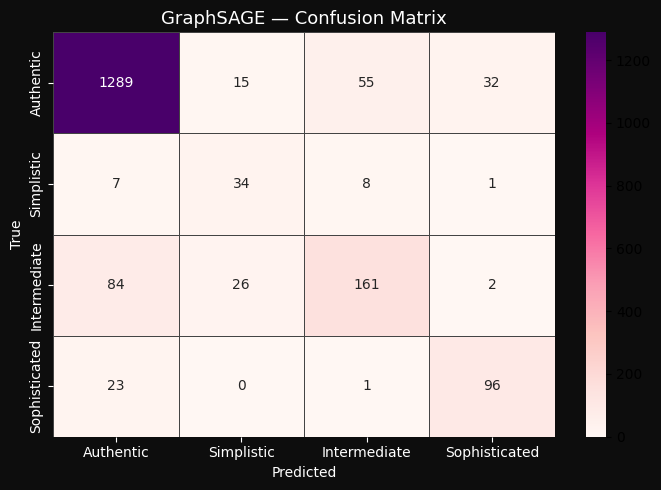

  Computing t-SNE for GraphSAGE...


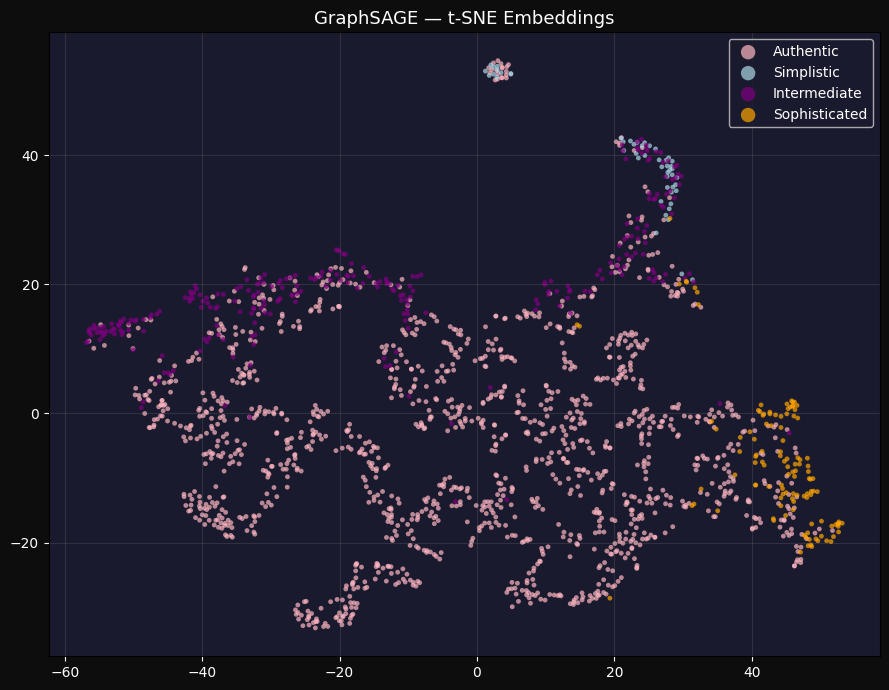

In [150]:
class GraphSAGE(nn.Module):
    def __init__(self, in_f=IN_FEATURES, hidden=128, out=N_CLASSES):
        super().__init__()
        self.conv1 = SAGEConv(in_f, hidden)
        self.conv2 = SAGEConv(hidden, hidden)
        self.conv3 = SAGEConv(hidden, 64)
        self.bn1 = nn.BatchNorm1d(hidden)
        self.bn2 = nn.BatchNorm1d(hidden)
        self.bn3 = nn.BatchNorm1d(64)
        self.classifier = nn.Sequential( nn.Linear(64 * 2, 64), nn.ReLU(), nn.Dropout(0.3), nn.Linear(64, out) )

    def forward(self, x, edge_index, edge_attr, batch):
        x = F.relu(self.bn1(self.conv1(x, edge_index)))
        x = F.dropout(x, p=0.3, training=self.training)
        x = F.relu(self.bn2(self.conv2(x, edge_index)))
        x = F.relu(self.bn3(self.conv3(x, edge_index)))
        x = torch.cat([global_mean_pool(x, batch), global_max_pool(x, batch)], dim=1)
        return self.classifier(x)

print("2. GraphSAGE")
sage_model, sage_history = train_model(GraphSAGE(), "GraphSAGE", epochs=50)
sage_results = full_eval(sage_model, "GraphSAGE", sage_history)

GAT

3. GAT — Graph Attention Network
  [GAT] Epoch  10 | Train loss: 0.7228 acc: 0.7586 | Val loss: 0.8177 acc: 0.7589
  [GAT] Epoch  20 | Train loss: 0.7030 acc: 0.7590 | Val loss: 0.8594 acc: 0.7589
  [GAT] Epoch  30 | Train loss: 0.6564 acc: 0.7622 | Val loss: 0.9378 acc: 0.7589
  [GAT] Epoch  40 | Train loss: 0.6299 acc: 0.7625 | Val loss: 0.9823 acc: 0.7589
  [GAT] Epoch  50 | Train loss: 0.6160 acc: 0.7661 | Val loss: 1.0441 acc: 0.7589
Saved: GAT_best.pt (best val acc: 0.759)
GAT — TEST RESULTS
Accuracy: 0.758
F1 macro: 0.216

               precision    recall  f1-score   support

    Authentic       0.76      1.00      0.86      1391
   Simplistic       0.00      0.00      0.00        50
 Intermediate       0.00      0.00      0.00       273
Sophisticated       0.00      0.00      0.00       120

     accuracy                           0.76      1834
    macro avg       0.19      0.25      0.22      1834
 weighted avg       0.58      0.76      0.65      1834



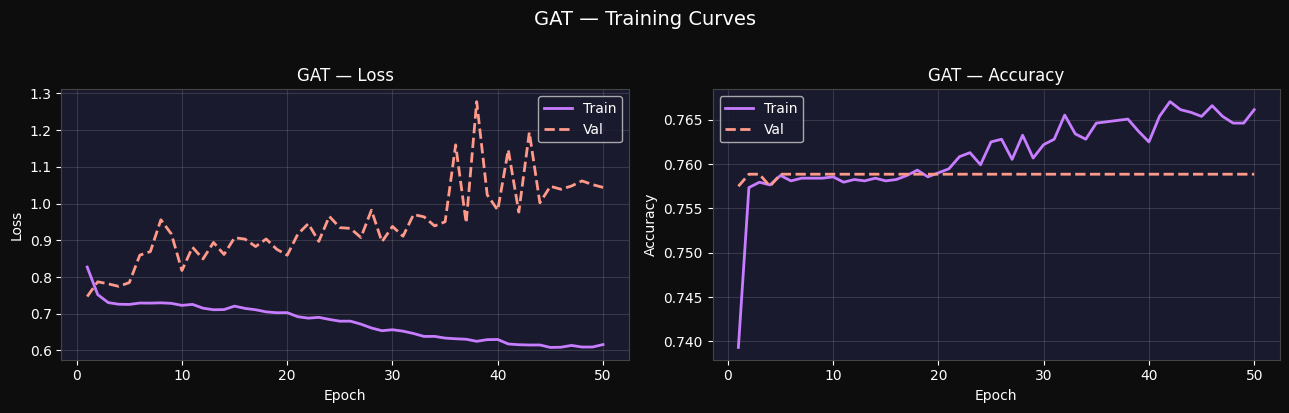

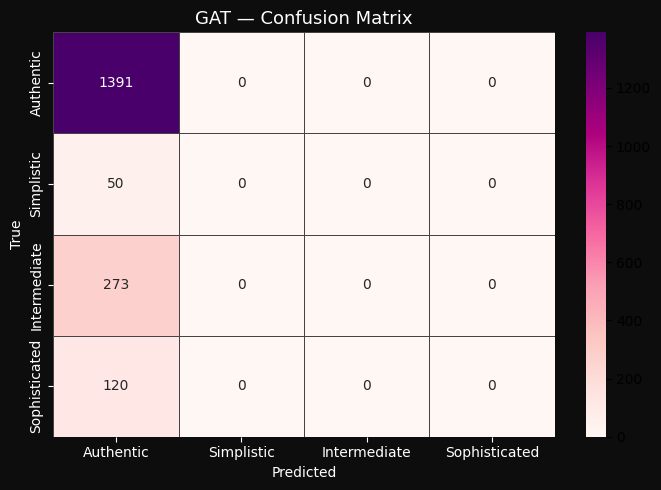

  Computing t-SNE for GAT...


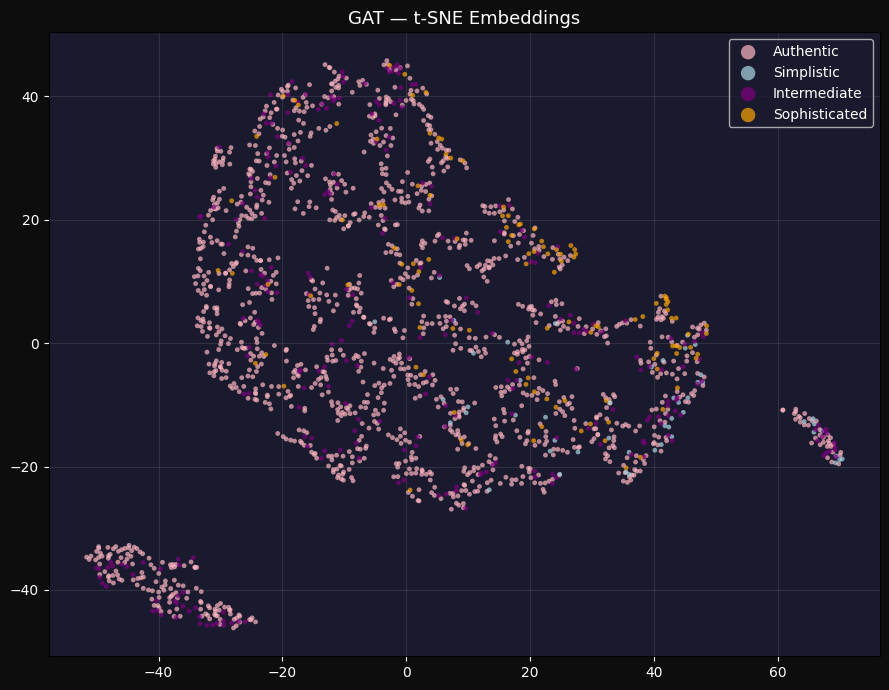

In [151]:
class GAT(nn.Module):
    def __init__(self, in_f=IN_FEATURES, hidden=64, out=N_CLASSES, heads=4):
        super().__init__()
        self.conv1 = GATConv(in_f, hidden, heads=heads, dropout=0.3, edge_dim=1)
        self.conv2 = GATConv(hidden*heads,  hidden, heads=heads, dropout=0.3, edge_dim=1)
        self.conv3 = GATConv(hidden*heads,  64, heads=1, concat=False, dropout=0.3, edge_dim=1)
        self.bn1 = nn.BatchNorm1d(hidden * heads)
        self.bn2 = nn.BatchNorm1d(hidden * heads)
        self.bn3 = nn.BatchNorm1d(64)
        self.classifier = nn.Sequential(nn.Linear(64 * 2, 64), nn.ReLU(), nn.Dropout(0.3),nn.Linear(64, out))

    def forward(self, x, edge_index, edge_attr, batch):
        x = F.elu(self.bn1(self.conv1(x, edge_index, edge_attr)))
        x = F.dropout(x, p=0.3, training=self.training)
        x = F.elu(self.bn2(self.conv2(x, edge_index, edge_attr)))
        x = F.elu(self.bn3(self.conv3(x, edge_index, edge_attr)))
        x = torch.cat([global_mean_pool(x, batch), global_max_pool(x, batch)], dim=1)
        return self.classifier(x)

print("3. GAT — Graph Attention Network")
gat_model, gat_history = train_model(GAT(), "GAT", epochs=50)
gat_results = full_eval(gat_model, "GAT", gat_history)

GAE

In [152]:
class GCNEncoder(nn.Module):
    def __init__(self, in_f=IN_FEATURES, hidden=128, latent=64):
        super().__init__()
        self.conv1 = GCNConv(in_f, hidden)
        self.conv2 = GCNConv(hidden,latent)
        self.bn1 = nn.BatchNorm1d(hidden)

    def forward(self, x, edge_index, edge_weight=None):
        x = F.relu(self.bn1(self.conv1(x, edge_index, edge_weight)))
        return self.conv2(x, edge_index, edge_weight)

authentic_idx = [i for i in idx_train if pyg_all[i].y.item() == 0]
gae_loader = DataLoader([pyg_all[i] for i in authentic_idx], batch_size=64, shuffle=True)

encoder = GCNEncoder().to(DEVICE)
gae_model = GAE(encoder).to(DEVICE)
gae_opt = torch.optim.Adam(gae_model.parameters(), lr=0.001)

print("4. GAE — Graph Autoencoder (anomaly detection)")

gae_losses = []
for epoch in range(1, 51):
    gae_model.train()
    total_loss = 0
    for batch in gae_loader:
        batch = batch.to(DEVICE)
        ew = batch.edge_attr.squeeze(-1)
        gae_opt.zero_grad()
        z = gae_model.encode(batch.x, batch.edge_index, ew)
        loss = gae_model.recon_loss(z, batch.edge_index)
        loss.backward()
        gae_opt.step()
        total_loss += loss.item()
    gae_losses.append(total_loss / len(gae_loader))
    if epoch % 10 == 0:
        print(f"[GAE] Epoch {epoch:3d} | Recon loss: {gae_losses[-1]:.4f}")

torch.save(gae_model.state_dict(), os.path.join(MODELS_DIR, "gae_best.pt"))
print("Saved: gae_best.pt")

4. GAE — Graph Autoencoder (anomaly detection)
[GAE] Epoch  10 | Recon loss: 1.2252
[GAE] Epoch  20 | Recon loss: 1.2053
[GAE] Epoch  30 | Recon loss: 1.2029
[GAE] Epoch  40 | Recon loss: 1.1945
[GAE] Epoch  50 | Recon loss: 1.1896
Saved: gae_best.pt


In [153]:

# GAE evaluation- anomaly scores per test graph
@torch.no_grad()
def gae_anomaly_scores(model, loader):
    model.eval()
    scores, labels = [], []
    for batch in loader:
        batch = batch.to(DEVICE)
        ew = batch.edge_attr.squeeze(-1)
        z  = model.encode(batch.x, batch.edge_index, ew)
        adj_recon = torch.sigmoid(z @ z.T) # Reconstruction error per graf
        n = batch.x.size(0)
        adj_true = torch.zeros(n, n, device=DEVICE)
        adj_true[batch.edge_index[0], batch.edge_index[1]] = 1.0
        recon_err = F.mse_loss(adj_recon, adj_true, reduction="none").mean().item()
        scores.append(recon_err)
        labels.append(batch.y[0].item())
    return np.array(scores), np.array(labels)

In [154]:
gae_scores, gae_labels = gae_anomaly_scores(gae_model, test_loader)

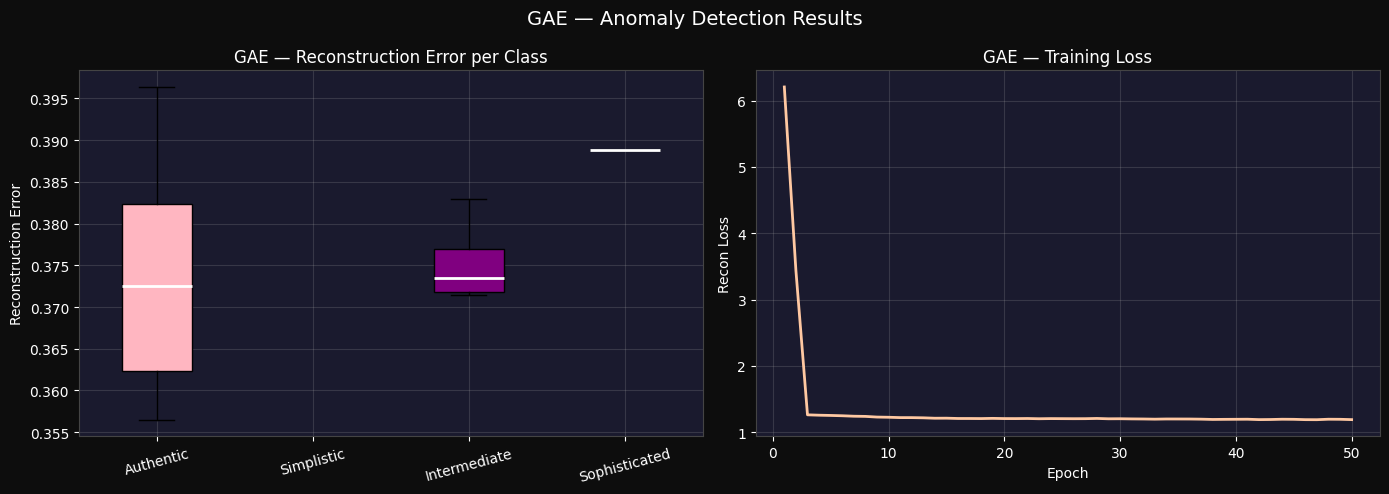


  GAE Binary Detection (threshold=0.3931)
  Accuracy: 0.7586 | F1 macro: 0.4314


In [158]:
# anomaly scores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("#0d0d0d")

for ax in axes:
    ax.set_facecolor("#1a1a2e")
    ax.tick_params(colors="white")
    for spine in ax.spines.values():
        spine.set_edgecolor("#444")

#boxplot per class
data_by_class = [gae_scores[gae_labels == c] for c in range(4)]
bp = axes[0].boxplot(data_by_class, patch_artist=True, medianprops=dict(color="white", linewidth=2))
for patch, cls in zip(bp['boxes'], range(4)):
    patch.set_facecolor(CLASS_COLORS[cls])
axes[0].set_xticklabels(list(CLASS_NAMES.values()), color="white", rotation=15)
axes[0].set_title("GAE — Reconstruction Error per Class", color="white", fontsize=12)
axes[0].set_ylabel("Reconstruction Error", color="white")
axes[0].grid(alpha=0.2)

# training loss
axes[1].plot(range(1, 51), gae_losses, color="#ffc8a2", lw=2)
axes[1].set_title("GAE — Training Loss", color="white", fontsize=12)
axes[1].set_xlabel("Epoch", color="white")
axes[1].set_ylabel("Recon Loss", color="white")
axes[1].grid(alpha=0.2)

plt.suptitle("GAE — Anomaly Detection Results", color="white", fontsize=14)
plt.tight_layout()
plt.show()

# threshold-based binary detection
threshold = np.percentile(gae_scores[gae_labels == 0], 95)
gae_preds_binary = (gae_scores > threshold).astype(int)
gae_true_binary = (gae_labels > 0).astype(int)
gae_acc = accuracy_score(gae_true_binary, gae_preds_binary)
gae_f1 = f1_score(gae_true_binary, gae_preds_binary, average="macro")
print(f"\n  GAE Binary Detection (threshold={threshold:.4f})")
print(f" Accuracy: {gae_acc:.4f} | F1 macro: {gae_f1:.4f}")
gae_results = {"model": "GAE", "accuracy": gae_acc, "f1_macro": gae_f1}

5. Hybrid - GAT + GCN

  [Hybrid] Epoch  10 | Train loss: 0.5928 acc: 0.7622 | Val loss: 0.8066 acc: 0.7589
  [Hybrid] Epoch  20 | Train loss: 0.5422 acc: 0.7663 | Val loss: 0.7761 acc: 0.7589
  [Hybrid] Epoch  30 | Train loss: 0.5024 acc: 0.7775 | Val loss: 0.9206 acc: 0.7575
  [Hybrid] Epoch  40 | Train loss: 0.4868 acc: 0.7823 | Val loss: 1.0317 acc: 0.7534
  [Hybrid] Epoch  50 | Train loss: 0.4658 acc: 0.7955 | Val loss: 1.0930 acc: 0.7452
Saved: Hybrid_best.pt (best val acc: 0.760)
Hybrid — TEST RESULTS
Accuracy: 0.759
F1 macro: 0.235

               precision    recall  f1-score   support

    Authentic       0.76      1.00      0.86      1391
   Simplistic       0.00      0.00      0.00        50
 Intermediate       0.00      0.00      0.00       273
Sophisticated       0.56      0.04      0.08       120

     accuracy                           0.76      1834
    macro avg       0.33      0.26      0.24      1834
 weighted avg       0.61      0.76      0.66      1834



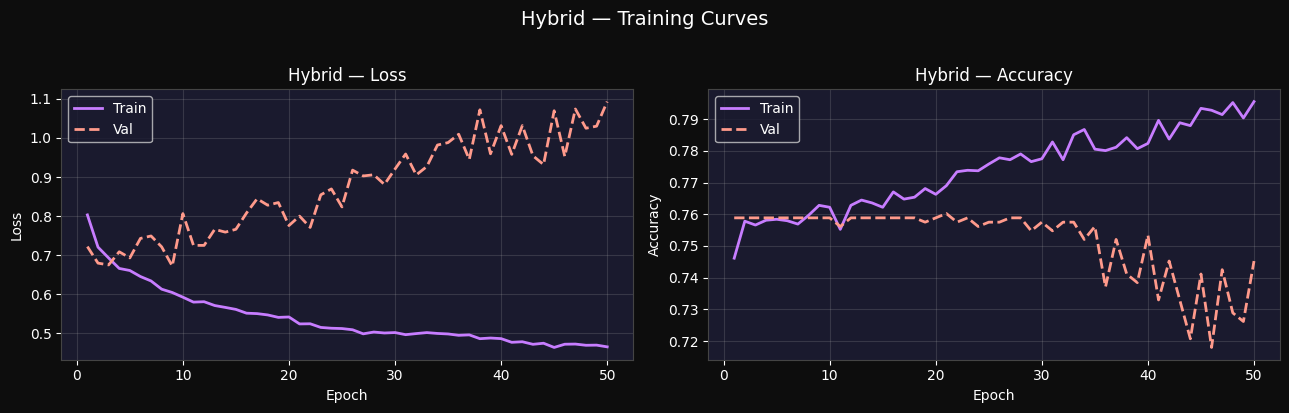

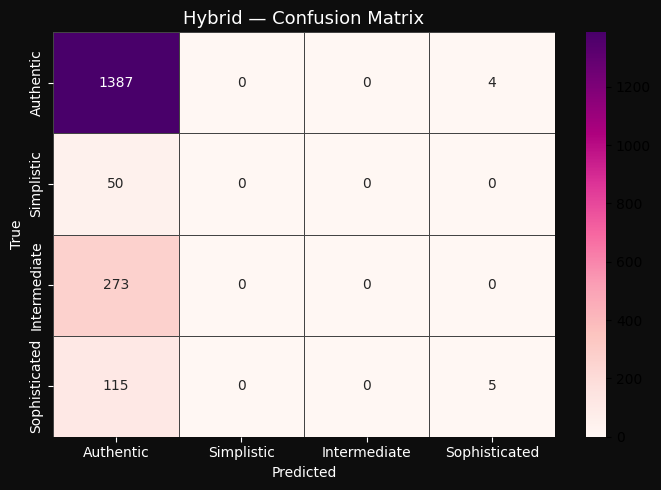

  Computing t-SNE for Hybrid...


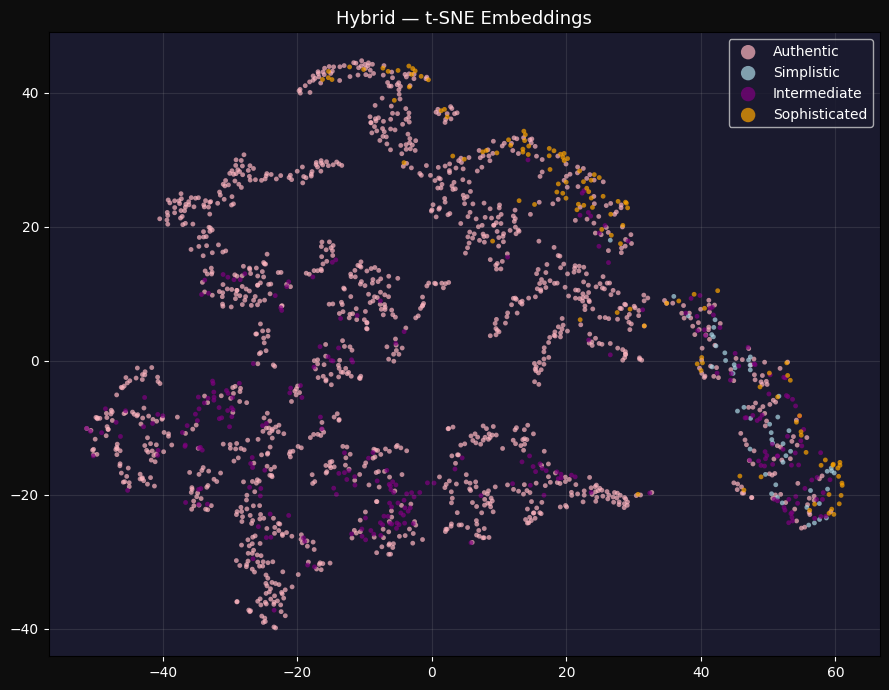

In [160]:
class HybridGNN(nn.Module):
    """
    GAT branch -> corr weights
    GCN branch -> convolutions
    combining
    """
    def __init__(self, in_f=IN_FEATURES, hidden=64, out=N_CLASSES, heads=4):
        super().__init__()
        # GAT attention
        self.gat1 = GATConv(in_f,hidden, heads=heads,dropout=0.3, edge_dim=1)
        self.gat2 = GATConv(hidden*heads, hidden, heads=1, concat=False, dropout=0.3, edge_dim=1)
        self.bn_gat1 = nn.BatchNorm1d(hidden*heads)
        self.bn_gat2 = nn.BatchNorm1d(hidden)

        # GCN conv
        self.gcn1 = GCNConv(in_f, hidden)
        self.gcn2 = GCNConv(hidden, hidden)
        self.bn_gcn1 = nn.BatchNorm1d(hidden)
        self.bn_gcn2 = nn.BatchNorm1d(hidden)

        # combining
        self.classifier = nn.Sequential(
            nn.Linear(hidden * 4, 128),
            nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, out)
        )

    def forward(self, x, edge_index, edge_attr, batch):
        ew = edge_attr.squeeze(-1) if edge_attr is not None else None

        # GAT branch
        g = F.elu(self.bn_gat1(self.gat1(x, edge_index, edge_attr)))
        g = F.dropout(g, p=0.3, training=self.training)
        g = F.elu(self.bn_gat2(self.gat2(g, edge_index, edge_attr)))
        g_pool = torch.cat([global_mean_pool(g, batch),global_max_pool(g, batch)], dim=1)

        # GCN branch
        c = F.relu(self.bn_gcn1(self.gcn1(x, edge_index, ew)))
        c = F.dropout(c, p=0.3, training=self.training)
        c = F.relu(self.bn_gcn2(self.gcn2(c, edge_index, ew)))
        c_pool = torch.cat([global_mean_pool(c, batch), global_max_pool(c, batch)], dim=1)

        # concat two models
        fused = torch.cat([g_pool, c_pool], dim=1)
        return self.classifier(fused)

hybrid_model, hybrid_history = train_model(HybridGNN(), "Hybrid", epochs=50)
hybrid_results = full_eval(hybrid_model, "Hybrid", hybrid_history)

Evaluation of every trained GNN model using plot

Model comparison
           accuracy  f1_macro
model                        
GCN          0.7666    0.2650
GraphSAGE    0.8615    0.7196
GAT          0.7585    0.2157
GAE          0.7586    0.4314
Hybrid       0.7590    0.2350


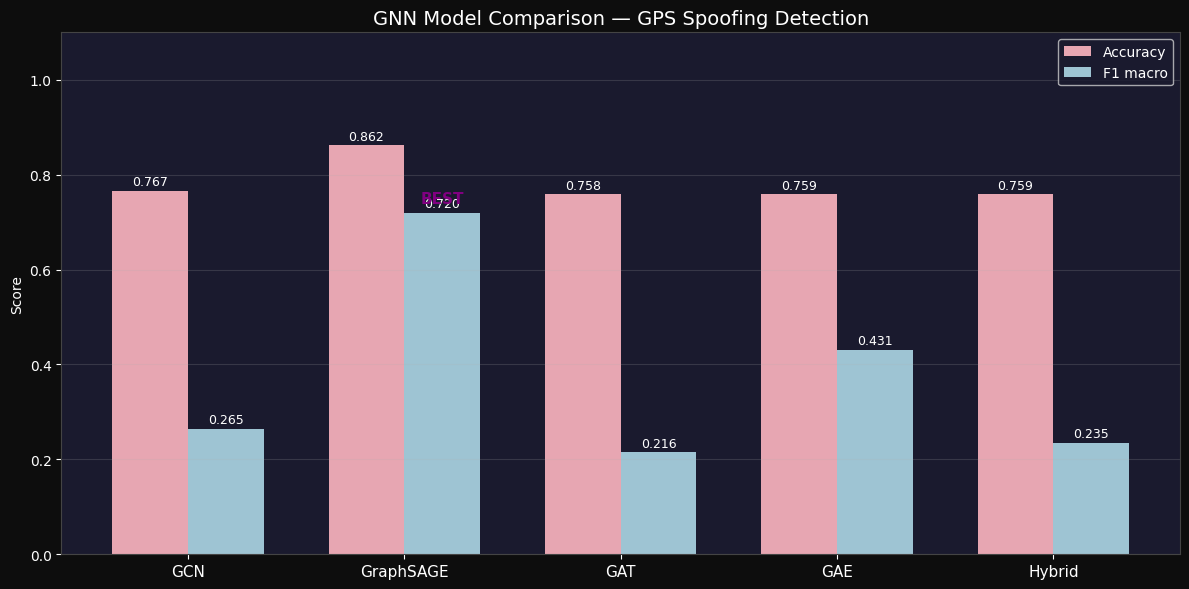


GNN saved: /content/drive/MyDrive/kosciuszkon/models/gnn_results_summary.csv


In [161]:

all_results = [gcn_results, sage_results, gat_results, gae_results, hybrid_results]
results_df = pd.DataFrame(all_results).set_index("model")
print("Model comparison")
print(results_df.round(4).to_string())

# plotting
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor("#0d0d0d")
ax.set_facecolor("#1a1a2e")
ax.tick_params(colors="white")
ax.xaxis.label.set_color("white")
ax.yaxis.label.set_color("white")
for spine in ax.spines.values():
    spine.set_edgecolor("#444")

models = results_df.index.tolist()
accs = results_df["accuracy"].values
f1s = results_df["f1_macro"].values
x = np.arange(len(models))
w = 0.35

bars1 = ax.bar(x - w/2, accs, width=w, label="Accuracy", color="lightpink", alpha=0.9)
bars2 = ax.bar(x + w/2, f1s,  width=w, label="F1 macro",  color="lightblue", alpha=0.9)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha="center", va="bottom",
            color="white", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha="center", va="bottom",
            color="white", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(models, color="white", fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score", color="white")
ax.set_title("GNN Model Comparison — GPS Spoofing Detection", color="white", fontsize=14)
ax.legend(facecolor="#1a1a2e", labelcolor="white")
ax.grid(axis="y", alpha=0.2)

# best
best_idx = np.argmax(f1s)
ax.annotate("BEST", xy=(x[best_idx] + w/2, f1s[best_idx] + 0.02), color="purple", fontsize=11, ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

# saving to table
results_df.to_csv(os.path.join(MODELS_DIR, "gnn_results_summary.csv"))
print(f"\nGNN saved: {MODELS_DIR}/gnn_results_summary.csv")